In [1]:
# data_path = 'C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'
data_path = 'W:/Pt+C paper/Data z PEMWE/'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import wepy as we
from scipy.optimize import curve_fit

def custom_format(x, pos):
    return r"${:,}$".format(int(x)).replace(',', r'\,')


# plt.rcParams['text.usetex'] = True
# plt.rcParams['axes.formatter.use_locale'] = True

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": "Times New Roman"
# })


s006 = {'name':'006', "loading" : "116 nm Pt"}
s016 = {'name':'016', "loading" : "116 nm Pt"}
s014 = {'name':'014', "loading" : "58 nm Pt 58 nm C"}
s019 = {'name':'019', "cycles" : 9, "loading" : "58 nm Pt 58 nm C"}
s021 = {'name':'021', "cycles" : 9, "loading" : "58 nm Pt 58 nm C"}
s028 = {'name':'028', "cycles" : 16, "loading" : "GDE","best_cycle" : 8}
s029 = {'name':'029', "cycles" : 16, "loading" : "116 nm Pt", "best_cycle" : 15,  "offset" : 0}
s034 = {'name':'034', "cycles" : 16, "loading" : "58 nm Pt",'label' : 'MEA 60Pt'}
s041 = {'name':'041', "cycles" : 16, "loading" : "58 nm Pt +  58 nm C",'label' : 'MEA 60Pt60C',"best_cycle" : 9,  "offset" : 0}
s042 = {'name':'042', "cycles" : 16, "loading" : "29 nm Pt +  87 nm C","best_cycle" : 22, "offset" : 3} 
s044 = {'name':'044', "cycles" : 16, "loading" : "Pt + C cosputtering"}
s046 = {'name':'046', "cycles" : 16, "loading" : "14 nm Pt +  102 nm C",'label' : 'MEA 15Pt105C',"best_cycle" : 24,  "offset" : 0}
s047 = {'name':'047', "cycles" : 16, "loading" : "14 nm Pt",'label' : 'MEA 15Pt'}
s049 = {'name':'049', "cycles" : 16, "loading" : "7 nm Pt +  105 nm C","best_cycle" : 37, "offset" : 2}
s050 = {'name':'050', "cycles" : 16, "loading" : "4 nm Pt +  108 nm C","best_cycle" : 7, "offset" : 1}
s055 = {'name':'055', "cycles" : 16, "loading" : "7 nm Pt +  58 nm C"}
s065 = {'name':'065', "cycles" : 16, "loading" : "7 nm Pt +  29 nm C"}
s076 = {'name':'076', "cycles" : 16, "loading" : "7 nm Pt +  14 nm C"}
s079 = {'name':'079', "cycles" : 16, "loading" : "Cosputtering Pt 5 W C 300 W 60 min"}
s091 = {'name':'091', "cycles" : 18, "loading" : "7 nm Pt", "position" : "3-2-LH"}
s092 = {'name':'092', "cycles" : 18, "loading" : "4 nm Pt + 29 nm C", "position" : "3-2-LH"}
s093 = {'name':'093', "cycles" : 10, "loading" : "0 nm Pt", "position" : "3-2-LH"}
s094 = {'name':'094', "cycles" : 18, "loading" : "7 nm Pt + 7 nm C", "position" : "3-2-LH"}
s096 = {'name':'096', "loading" : "60 nm PtO", "position" : "3-1-LH"}
s097 = {'name':'097', "loading" : "15 nm PtO", "position" : "3-1-LS"}
s098 = {'name':'098', "loading" : "7 nm Pt", "position" : "3-1-LS"}
s109 = {'name':'109', "loading" : "7 nm Pt on 5 nm Fe", "position" : "4-1-?"}
s111 = {'name':'111', "loading" : "2 nm Fe + 7 nm Pt + 30 nm C", "position" : "4-1-?"}
s120 = {'name':'120', "loading" : "7 nm Pt + 15 nm C", "position" : "4-1-?"}
s143 = {'name':'143', "loading" : "7 nm Pt + 15 nm C", "position" : "4-1-?"}
s153 = {'name':'153', "loading" : "7 nm Pt + 15 nm C", "position" : "4-1-?"}


Imported basics
Imported loopeis
Imported eis


## Fig 1

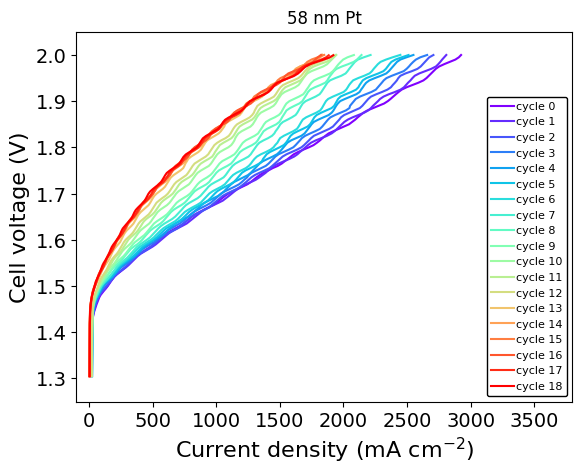

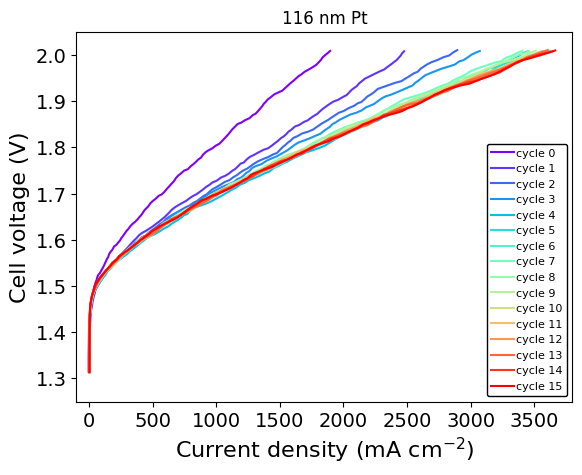

In [8]:
MEA = [s034,s029]
# %matplotlib ipympl

cmap = plt.get_cmap('rainbow')
for mea in MEA:
    plt.close()
    # folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*')  
    mea['files'] = glob(os.path.join(data_path+mea['name']+'*/SV',mea['name']+'_cycle_rising*'+'*.txt'))
    colors = cmap(np.linspace(0,1,len(mea['files'])))
    for cycle in range(0,len(mea['files'])):
        d = np.loadtxt(mea['files'][cycle],skiprows=1) 
        I = d[:,0] 
        U = d[:,1] 
        plt.plot(I/4.84,U,'-',label = 'cycle '+str(cycle),c=colors[cycle])  

        plt.ylim(1.25,2.05)     
        # plt.annotate("", xytext=(3000, 2.05), xy=(4000, 2.05), arrowprops=dict(arrowstyle="->"))
        # plt.annotate("", xytext=(2800, 2.05), xy=(1800, 2.05), arrowprops=dict(arrowstyle="->"))
        plt.legend(loc='lower right',handletextpad=0.2,fontsize=8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
        plt.ylabel('Cell voltage (V)',size=16)
        plt.xlabel(r'Current density $\mathrm{\left( mA ~ cm^{-2} \right) }$',size=16)
        plt.xticks(size = 14)
        plt.yticks(size = 14)
        plt.title(mea['loading'])
        plt.xlim(-100,3800)
        # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/IV,58Pt,58PtC,GDE,116Pt.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
    plt.show()      

## Fig 2

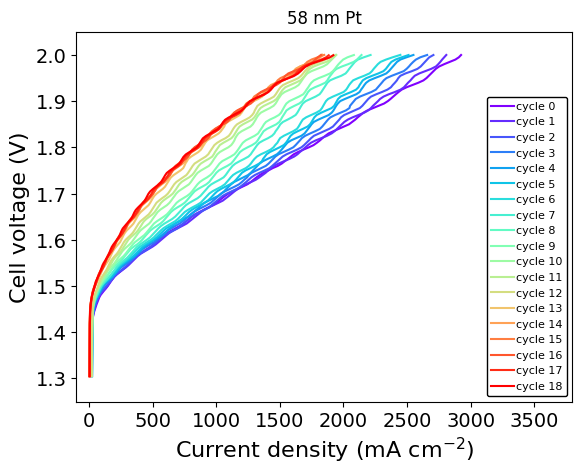

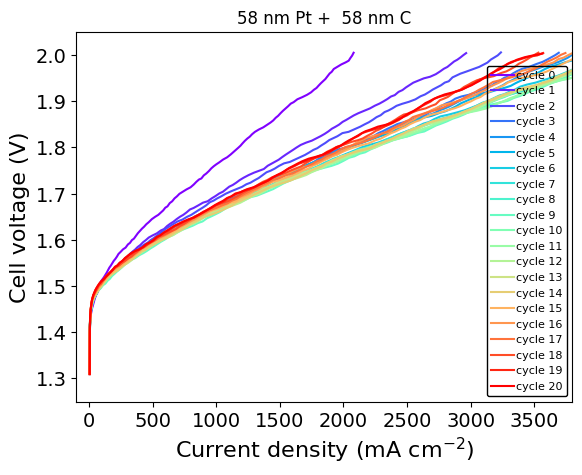

In [9]:
MEA = [s034,s041]
# %matplotlib ipympl

cmap = plt.get_cmap('rainbow')
for mea in MEA:
    plt.close()
    # folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*')  
    mea['files'] = glob(os.path.join(data_path+mea['name']+'*/SV',mea['name']+'_cycle_rising*'+'*.txt'))
    colors = cmap(np.linspace(0,1,len(mea['files'])))
    for cycle in range(0,len(mea['files'])):
        d = np.loadtxt(mea['files'][cycle],skiprows=1) 
        I = d[:,0] 
        U = d[:,1] 
        plt.plot(I/4.84,U,'-',label = 'cycle '+str(cycle),c=colors[cycle])  

        plt.ylim(1.25,2.05)     
        # plt.annotate("", xytext=(3000, 2.05), xy=(4000, 2.05), arrowprops=dict(arrowstyle="->"))
        # plt.annotate("", xytext=(2800, 2.05), xy=(1800, 2.05), arrowprops=dict(arrowstyle="->"))
        plt.legend(loc='lower right',handletextpad=0.2,fontsize=8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
        plt.ylabel('Cell voltage (V)',size=16)
        plt.xlabel(r'Current density $\mathrm{\left( mA ~ cm^{-2} \right) }$',size=16)
        plt.xticks(size = 14)
        plt.yticks(size = 14)
        plt.title(mea['loading'])
        plt.xlim(-100,3800)
        # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/IV,58Pt,58PtC,GDE,116Pt.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
    plt.show()      

## Fig 3

029 0
041 1
042 2
046 3
049 4
050 5
028 6
034 7


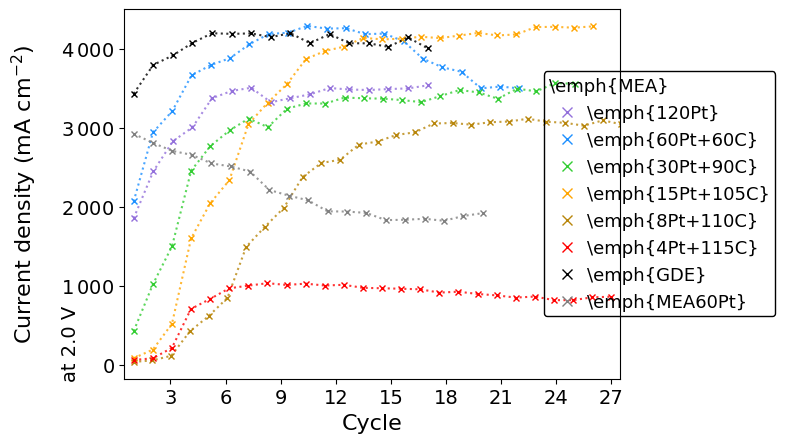

In [3]:
MEA = [s029,s041,s042,s046,s049,s050,s028,s034]
# labels = ['\emph{MEA 120Pt}','\emph{MEA 60Pt+60C}','\emph{MEA 30Pt+90C}','\emph{MEA 15Pt+105C}','\emph{MEA 8Pt+110C}','\emph{MEA 4Pt+115C}','\emph{MEA GDE}']
labels = ['\emph{120Pt}','\emph{60Pt+60C}','\emph{30Pt+90C}','\emph{15Pt+105C}','\emph{8Pt+110C}','\emph{4Pt+115C}','\emph{GDE}','\emph{MEA60Pt}']

for mea in MEA:
    folder_path = glob(data_path+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['red', 'darkgoldenrod','orange' , 'limegreen', 'dodgerblue', 'mediumpurple']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
voltage = [2]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
for uc,u in enumerate(voltage):
    lines = []
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        if mea['name'] == '028':
            line,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c='black')
            plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c='black',alpha = 0.8)
        elif mea['name'] == '034':
            line,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c='grey')
            plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c='grey',alpha = 0.8)
        else:
            line,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c=colors[5-index])
            plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[5-index],alpha = 0.8)
        lines.append(line)

        print(mea['name'],index)
        
    plt.xlim(1,15)
    # print(mea['iatu'][uc])
    custom_order = [0, 3, 1, 4, 2, 5, 6] 
    
    plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.5),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

    xticks = np.arange(0, 30, 3)  # Every third tick
    xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
    plt.xticks(xticks, xlabels,size = 14)
    plt.xlim(0.5,27.5)
    # plt.text(21,1500,r'$V = \mathrm{2.0~V}$',size = 18)
    plt.yticks(size = 14)
    plt.xlabel("Cycle",size=16)
    plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16,labelpad = 16)
    # plt.text(-3.2, 2000, "at 1.6 V", rotation=90, va='center', ha='center', fontsize=14)
    plt.text(-2.45, 280, "at 2.0 V", rotation=90, va='center', ha='center', fontsize=14)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/stability_high_C_'+str(u)+'.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
    plt.show()

## Fig. 4

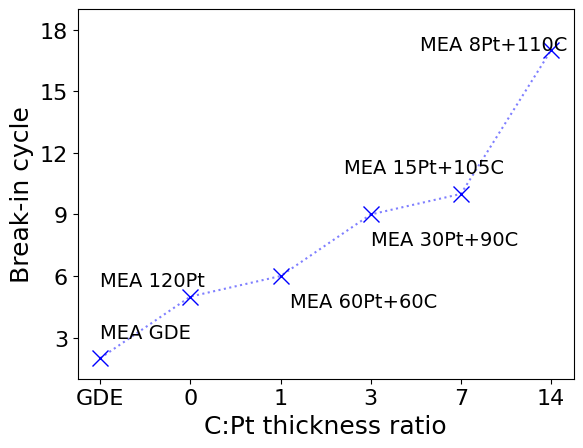

In [5]:
MEA = [s028,s029,s041,s042,s046,s049]

for mea in MEA:
    folder_path = glob(data_path+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


voltage = [2]
# voltage = [1.6,1.7,1.8,1.9,2]
for mea in MEA:
    # mea['iatu'] = [[],[],[],[],[]]
    mea['iatu'] = [[]]
    for cycle,file in enumerate(mea['files']):
        d = np.loadtxt(file)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)

cmap = plt.get_cmap('rainbow')

labels = ['GDE','0','1:1','3:1','7:1','15:1']
ratio = [0.25,0.5,1,3,7,15]
for uc,u in enumerate(voltage):
    break_ins = []
    for i,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        # plt.plot(t,np.array(mea['iatu'][uc])/4.84,label = labels[i],c=colors[i])
        threshold = 0.9*np.max(mea['iatu'][uc])/4.84
        
        
        index = next((i for i, x in enumerate(np.array(mea['iatu'][uc])/4.84) if x > threshold), None)
        # plt.axvline(index,color = colors[i],ls = '--')
        break_ins.append(index)

    # labels = ['120 nm Pt','60 nm Pt','30 nm Pt','15 nm Pt','8 nm Pt']
    xlabels = ["GDE","0","1","3","7","14"]
    xticks = [0,1,2,3,4,5]
    plt.plot(xticks,np.array(break_ins)+1,'x',markersize = '12', c = 'blue')
    plt.plot(xticks,np.array(break_ins)+1,':',markersize = '12', c = 'blue',alpha = 0.5)
    
    # xticks = [1,2,3,4,5]
    # for i,rati in enumerate(xlabels):
        
    # plt.ylim(-0.1,19)
    plt.text(0,3,'MEA GDE',size = 14)
    plt.text(0,5.5,'MEA 120Pt',size = 14)
    plt.text(2.1,4.5,'MEA 60Pt+60C',size = 14)
    plt.text(3,7.5,'MEA 30Pt+90C',size = 14)
    plt.text(2.7,11,'MEA 15Pt+105C',size = 14)
    plt.text(3.55,17,'MEA 8Pt+110C',size = 14)
    # labels = [,,'MEA 30Pt+90C','MEA 15Pt+105C','MEA 8Pt+110C']

    # plt.text(xticks[i]-0.1,np.array(break_ins)[i]-2,labels[i],size = 14)
    
    plt.xlabel('C:Pt thickness ratio',size = 18)
    plt.ylabel('Break-in cycle',size = 18)
    # plt.title('Break-in time at '+f'{u:.1f}'+' V',size = 20)


    # xlabels = ["0","1","3","7","15"]
    yticks = [0,3,6,9,12,15,18]
    # plt.xscale('log')
      # Label as 1, 2, 3, ...

    plt.xticks(xticks,xlabels,size = 16)
    plt.yticks(yticks,size = 16)
    plt.ylim(1,19)
    
#     plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/break-in high thickness series.png',dpi = 1000, format = 'png', bbox_inches = 'tight')


    plt.show()

## Fig. 5

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0
0
0
0


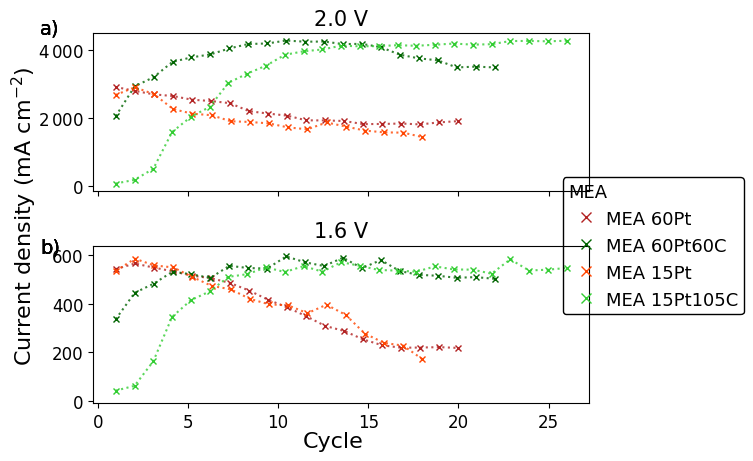

In [7]:
MEA = [s034,s041,s047,s046]

labels = ['120','60','30','15','8','4','GDE']
# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob(data_path+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['firebrick','darkgreen' ,'orangered','limegreen']

# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
fig, (ax1, ax2) = plt.subplots(2,1,sharex = True,gridspec_kw={'hspace': 0.35},)


voltage = [2,1.6]
for mea in MEA:
    mea['iatu'] = [[],[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)
                
                # print(index)
                # Iatu.append()
                # plt.plot(I[index],U[index],'x')
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        if uc == 0:
            print(uc)
            ax1.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = mea['label'],c=colors[index])
            ax1.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
            ax1.text(-3.2,4500,'a)',size = 14)
        else:
            # print(uc,mea['iatu'][uc])
            ax2.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = mea['label'],c=colors[index])
            ax2.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
            ax2.set_ylim(-10,640)
            ax2.text(-3.2,610,'b)',size = 14)

    plt.legend(title = 'MEA',loc='center right', bbox_to_anchor=(1.33, 1),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.4,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')


    
fig.supylabel(r'Current density $\mathrm{\left( mA ~ cm^{-2} \right) }$',size=16,x=-0.005)
fig.supxlabel('Cycle',size=16)
ax1.yaxis.set_major_formatter(FuncFormatter(custom_format))
ax1.set_title('2.0 V',size=15)
ax2.set_title('1.6 V',size=15)
ax1.tick_params(axis='both',labelsize = 12)
ax2.tick_params(axis='both',labelsize = 12)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/stability_PtxPt+C.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()

## Fig. 6

### Fig. 6a

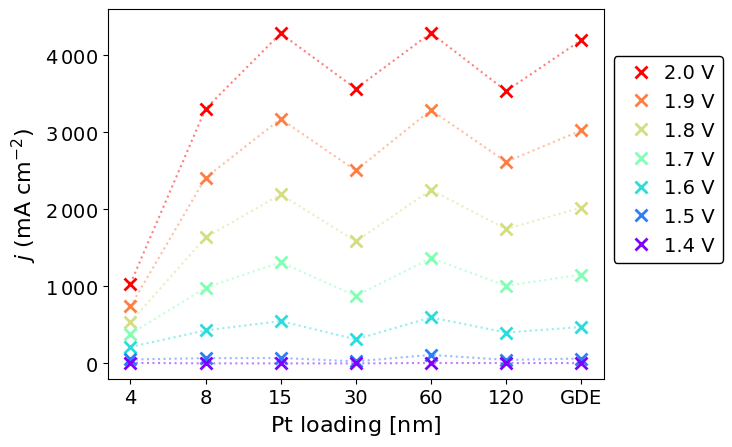

In [24]:

#Vybrat jestli je proudová hustota reálná, nebo specifická:::
spec = False


MEA = [s050,s049,s046,s042,s041,s029,s028]

soubory = []
for mea in MEA:
    folder_path = glob(data_path+mea['name']+'*/SV')   
    mea['file'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))[mea['best_cycle']]# print(glob(os.path.join('C:/Users/Herman/Desktop/MFF/Bakalarka/Data z PEMWE/SV/'+mea['name']+'_peak_performance.txt')))
    # mea['file'] = glob(os.path.join('C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'+mea['name']+'*/SV/',mea['name']+'_cycle_rising_*'+'*.txt'))mea['best_cycle']
    # glob(os.path.join('C:/Users/Herman/Desktop/MFF/Bakalarka/Data z PEMWE/SV/'+mea+'_peak_performance.txt'))
    # print(mea['file'])
    d = np.loadtxt(mea['file'], skiprows=1)
    I = d[:,0]
    U = d[:,1]
    mea['U'] = [1.4,1.5,1.6,1.7,1.8,1.9,2]
    mea['I'] = []
    for u in [1.4,1.5,1.6,1.7,1.8,1.9,2]:
        mea['I'].append(I[(np.abs(u - U)).argmin()])
#     print(mea['U'],mea['I'])
    # mea['U'] = d[:,0]
    # mea['I'] = d[:,3]

xlabels=['4','8','15','30','60','120','GDE']
loadings = [3.7,7.5,15,30,60,120,240]
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,7)) 
labels=['2.0 V','1.9 V','1.8 V','1.7 V','1.6 V','1.5 V','1.4 V']
xpos = [1,2,3,4,5,6,7]

for i,u in enumerate(labels):
    I_at_u = []
    for mea in MEA:
        I_at_u.append(mea['I'][-i-1])
    
    if spec == True:
        plt.plot(xpos, np.array(I_at_u)/(4.84*(np.array(loadings)*2.1+160)),':',c=colors[-1-i],alpha = 0.5)
        plt.plot(xpos,np.array(I_at_u)/(4.84*(np.array(loadings)*2.1+160)),'x',c=colors[-i-1],label = labels[i],markersize=8,mew=2)
    else:  
        plt.plot(xpos, np.array(I_at_u)/4.84,':',c=colors[-i-1],alpha = 0.5)
        plt.plot(xpos, np.array(I_at_u)/4.84,'x',c=colors[-i-1],label = labels[i],markersize=8,mew=2)

# plt.xticks(xlabels)
plt.legend(loc='upper left',bbox_to_anchor = (1,0.9),handletextpad=0.2,fontsize=14,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
# xticks = ['0.85','1.7','3.5','7','14','28','56','112','224']
plt.xticks(xpos,xlabels,size=14)
plt.yticks(size=14)
# plt.xlabel('Pt loading [$\mathrm{\mu g ~ cm^{-2}}$]',size=16)
plt.xlabel('Pt loading [$\mathrm{nm}$]',size=16)
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
 
if spec == True:
    plt.ylim(-1,24)
    plt.ylabel('$j_{\mathrm{spec}}$ ($\mathrm{mA}~\mathrm{\mu g}^{-1} $) ',size=16)

    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/performance_na_loadingu_normalizovana.png',dpi = 500, format = 'png', bbox_inches = 'tight')
else:
    plt.ylabel('$j$ ($\mathrm{mA~cm^{-2}}$) ',size=16)
    plt.ylim(-200,4601)
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/performance_na_loadingu_abs.png',dpi = 500, format = 'png', bbox_inches = 'tight')
plt.show()

### Fig. 6b

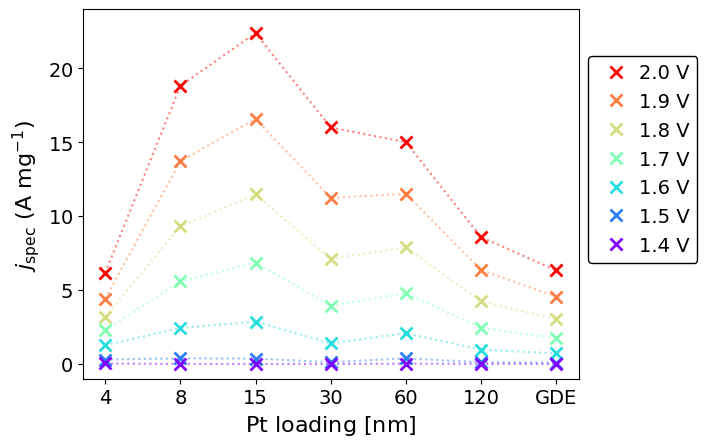

In [23]:

#Vybrat jestli je proudová hustota reálná, nebo specifická:::
spec = True


MEA = [s050,s049,s046,s042,s041,s029,s028]

soubory = []
for mea in MEA:
    folder_path = glob(data_path+mea['name']+'*/SV')   
    mea['file'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))[mea['best_cycle']]# print(glob(os.path.join('C:/Users/Herman/Desktop/MFF/Bakalarka/Data z PEMWE/SV/'+mea['name']+'_peak_performance.txt')))
    # mea['file'] = glob(os.path.join('C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'+mea['name']+'*/SV/',mea['name']+'_cycle_rising_*'+'*.txt'))mea['best_cycle']
    # glob(os.path.join('C:/Users/Herman/Desktop/MFF/Bakalarka/Data z PEMWE/SV/'+mea+'_peak_performance.txt'))
    # print(mea['file'])
    d = np.loadtxt(mea['file'], skiprows=1)
    I = d[:,0]
    U = d[:,1]
    mea['U'] = [1.4,1.5,1.6,1.7,1.8,1.9,2]
    mea['I'] = []
    for u in [1.4,1.5,1.6,1.7,1.8,1.9,2]:
        mea['I'].append(I[(np.abs(u - U)).argmin()])
#     print(mea['U'],mea['I'])
    # mea['U'] = d[:,0]
    # mea['I'] = d[:,3]

xlabels=['4','8','15','30','60','120','GDE']
loadings = [3.7,7.5,15,30,60,120,240]
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,7)) 
labels=['2.0 V','1.9 V','1.8 V','1.7 V','1.6 V','1.5 V','1.4 V']
xpos = [1,2,3,4,5,6,7]

for i,u in enumerate(labels):
    I_at_u = []
    for mea in MEA:
        I_at_u.append(mea['I'][-i-1])
    
    if spec == True:
        plt.plot(xpos, np.array(I_at_u)/(4.84*(np.array(loadings)*2.1+160)),':',c=colors[-1-i],alpha = 0.5)
        plt.plot(xpos,np.array(I_at_u)/(4.84*(np.array(loadings)*2.1+160)),'x',c=colors[-i-1],label = labels[i],markersize=8,mew=2)
    else:  
        plt.plot(xpos, np.array(I_at_u)/4.84,':',c=colors[-i-1],alpha = 0.5)
        plt.plot(xpos, np.array(I_at_u)/4.84,'x',c=colors[-i-1],label = labels[i],markersize=8,mew=2)

# plt.xticks(xlabels)
plt.legend(loc='upper left',bbox_to_anchor = (1,0.9),handletextpad=0.2,fontsize=14,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
# xticks = ['0.85','1.7','3.5','7','14','28','56','112','224']
plt.xticks(xpos,xlabels,size=14)
plt.yticks(size=14)
# plt.xlabel('Pt loading [$\mathrm{\mu g ~ cm^{-2}}$]',size=16)
plt.xlabel('Pt loading [$\mathrm{nm}$]',size=16)
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
 
if spec == True:
    plt.ylim(-1,24)
    plt.ylabel('$j_{\mathrm{spec}}$ ($\mathrm{A}~\mathrm{mg}^{-1} $) ',size=16)

    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/performance_na_loadingu_normalizovana.png',dpi = 500, format = 'png', bbox_inches = 'tight')
else:
    plt.ylabel('$j$ ($\mathrm{mA~cm^{-2}}$) ',size=16)
    plt.ylim(-200,4601)
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/performance_na_loadingu_abs.png',dpi = 500, format = 'png', bbox_inches = 'tight')
plt.show()

## Fig. 7

049 0
055 1
065 2
120 3
094 4
098 5
028 6


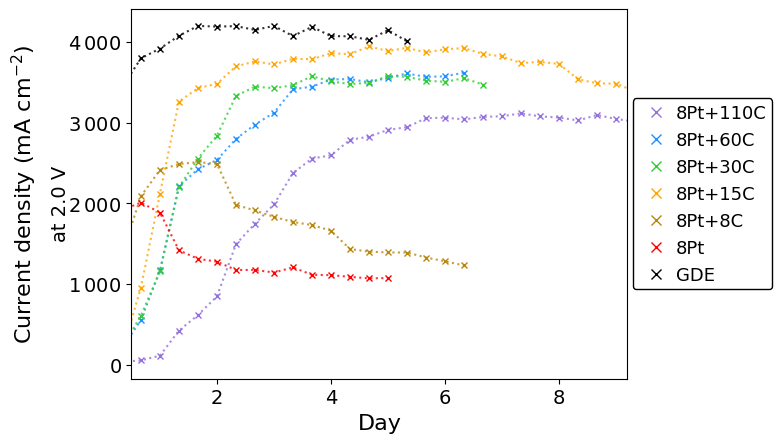

In [6]:
MEA = [s049,s055,s065,s120,s094,s098,s028] 

# labels = ['110','60','30','15','8','0','GDE']
labels = ['8Pt+110C','8Pt+60C','8Pt+30C','8Pt+15C','8Pt+8C','8Pt','GDE']

# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob(data_path+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['red', 'darkgoldenrod','orange' , 'limegreen', 'dodgerblue', 'mediumpurple']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [2]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)
                
                # print(index)
                # Iatu.append()
                # plt.plot(I[index],U[index],'x')
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles'],mea['cycles'])
        if mea['name'] == '028':
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c='black')
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,':',c='black',alpha = 0.8)
        else:
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c=colors[5-index])
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,':',c=colors[5-index],alpha = 0.8)
  

        print(mea['name'],index)
        
    
    plt.legend(loc='center right', bbox_to_anchor=(1.31, 0.5),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

    xticks = np.arange(0, 30, 2)  # Every third tick
    xlabels = [str(2*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
    
    plt.xticks(xticks, xlabels,size = 14)
    plt.yticks(size = 14)
    plt.xlabel("Day",size=16)
    # plt.ylabel(r'$\begin{array}{c}\text{Main Label} \\ \text{(units)}\end{array}$',size=16)
    plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16,labelpad = 21)
    plt.text(-0.75, 2000, "at 2.0 V", rotation=90, va='center', ha='center', fontsize=14)

    plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/8Pt+xC_loading_series_'+str(u)+'.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
    plt.xlim(0.5,9.2)
    plt.show()

# PEIS analysis

In [3]:
# Custom formatter function to specify decimal places
def format_with_precision(x, pos):
    return f"{x:.3f}"  # Change 3 to desired decimal places

def custom_format(x, pos):
    """Format ticks with specified values and no trailing zeros."""
    if x >= 1:
        return f"{int(x)}" if x.is_integer() else f"{x:.1f}".rstrip('0').rstrip('.')
    else:
        return f"{x:.10f}".rstrip('0').rstrip('.')  # For less than 1, use 2 decimal places

## Fig. 8

C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE\049_IV_IV_Ir etched star, Pt 7 nm + C 105 nm etched star\PEIS_time24_DC152.txt


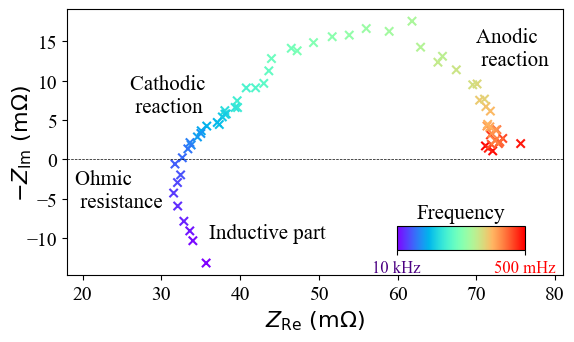

In [7]:

# plt.rcParams['text.usetex'] = True
# plt.rcParams['axes.formatter.use_locale'] = True

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": "Times New Roman"
})
# s049 = {'name':'049', "loading" : "7 nm Pt +  110 nm C"} # hotovo
MEA = [s049]
for mea in MEA:
    mea['files'] = glob(os.path.join('C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'+mea['name']+'*/','PEIS_time24*'))
    mea['files'].sort()
        #0.5 Hz až do 10000 Hz
plt.close()

# colors = ['orange','darkorange','red','darkred']
fig, ax = plt.subplots()

for i,file in enumerate(s049['files']):
    print(file)
    d = np.loadtxt(file,skiprows = 2,usecols = (0,1))
    Zre = 1000*d[:,0]
    Zim = 1000*d[:,1]
    im = ax.scatter(x=Zre,y=Zim,marker = 'x',c = np.linspace(1,0,len(Zre)),cmap = 'rainbow')


plt.xlabel(r'$Z_{\mathrm{Re}} ~ \mathrm{\left( m\Omega \right) }$',size=16)
plt.ylabel(r'$-Z_{\mathrm{Im}} ~ \mathrm{\left( m\Omega \right) }$',size=16,labelpad = -5)

plt.xticks(size = 14)
plt.yticks(size = 14)
plt.axhline(0,ls='--',c="black",lw=0.5)
plt.xlim(18,81)
plt.gca().set_aspect('equal')
plt.text(19,-6,"Ohmic \n resistance",size = 15)
plt.text(36,-10,"Inductive part",size = 15)
plt.text(70,12,"Anodic \n reaction",size = 15)
plt.text(26,6,"Cathodic \n reaction",size = 15)

cbar_ax = fig.add_axes([0.64, 0.27, 0.2, 0.05])
# cbar_ax = (0.125,0.125;0.775x0.775)
# print(type(cbar_ax))
cbar = fig.colorbar(im, orientation="horizontal", ticks=[0,1],cax = cbar_ax) 
# cbar.ax.tick_params(labelsize=15)
cbar.ax.set_title("Frequency", fontsize=15) 
cbar.set_ticks([0, 1])       # Specify tick positions
cbar.ax.set_xticklabels(["10 kHz","500 mHz"], fontsize=12)  # Custom labels

xticks = cbar.ax.get_xticks()
xticklabels = cbar.ax.get_xticklabels()

for label, color in zip(xticklabels, ['indigo', 'red']):
    label.set_color(color)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/PEIS_spectrum_examplex.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()

## Fig. 9

[[], [], [], [], [], [], [], [], []]
[[], [], [], [], [], [], []]


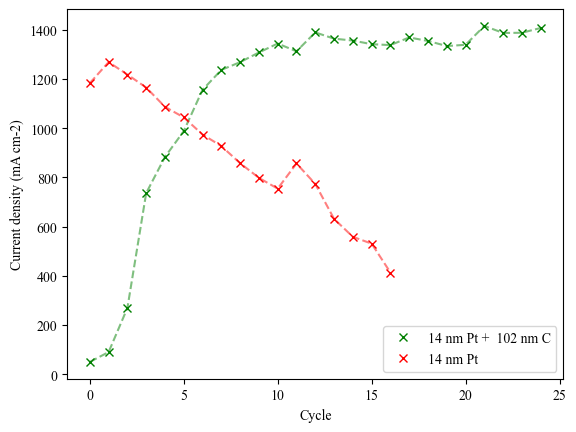

In [20]:
MEA = [s046,s047]
for mea,color in zip(MEA,['green','red']):
    files = glob(os.path.join(data_path+'*'+mea['name']+'*/Data z PEMWE/','*SV*'+'*.mpt'))
    files = we.files_without_ext(files)
    I = we.current_vs_time(files,U = 1.7, plot = False, norm = 4.84)
    plt.plot(I[0],'x', label = mea['loading'], c = color)
    plt.plot(I[0],'--', c = color, alpha = 0.5)
plt.xlabel('Cycle')
plt.ylabel('Current density (mA cm-2)')
plt.legend()
plt.show()
    

## Fig. 10

17
25


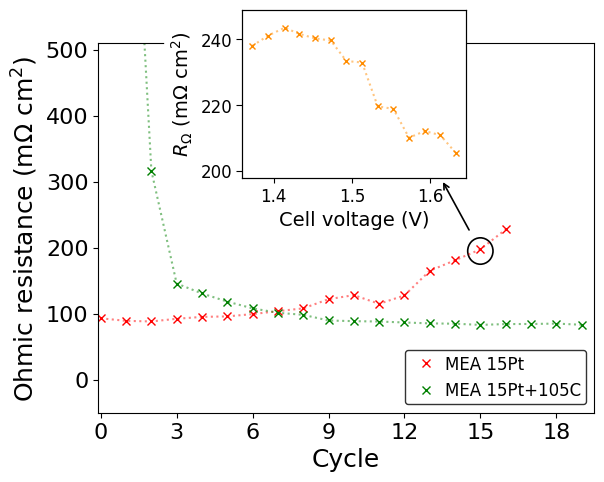

In [28]:
import matplotlib.patches as patches
from matplotlib.ticker import LogLocator, ScalarFormatter, FuncFormatter

s047 = {'name':'047', "loading" : "15 nm Pt"}
s046 = {'name':'046', "loading" : "15 nm Pt + 100 nm C"}
MEA = [s047,s046]

we.load_MEA_params(MEA)

for mea in MEA:     
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0,1,15))
    time = []
    for t in range(0,mea['cycles']):
        time.append(t)
    Ro_avg = 0
    for voltage in range(1,15):
        if mea['name'] == "046":
            Ro_avg += 1000*np.array((mea['Ro'][:,voltage]))[1:20]*4.84/14
        elif mea['name'] == "047":
            Ro_avg += 1000*np.array((mea['Ro'][:,voltage]))*4.84/14
            # plt.plot(np.array(time),(np.array((mea['Ro'][:,voltage])))*4.84,color = colors[voltage])
    if mea['name'] == "046":  
        plt.plot(np.array(time)[1:20],Ro_avg,'x',c="green",label = "MEA 15Pt+105C")
        plt.plot(np.array(time)[1:20],Ro_avg,':',c="green",alpha = 0.5)
    elif mea['name'] == "047":
        plt.plot(np.array(time),Ro_avg,'x',c="red",label = "MEA 15Pt")
        plt.plot(np.array(time),Ro_avg,':',c="red",alpha = 0.5)
plt.yticks(size = 16)

plt.xlim(-0.1,19.5)
plt.ylim(-50,510)

xticks = np.arange(0, 20, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...

plt.xticks(xticks, xlabels,size = 16)
plt.ylabel(r'Ohmic resistance $\mathrm{ \left(m \Omega ~ cm^{2} \right) }$',size=18)
plt.xlabel("Cycle",size=18)

plt.legend(fontsize = 12,loc='lower right',  ncol=1,handletextpad = 0.1, edgecolor = 'black',borderpad = 0.3)

plt.annotate(    '', xy=(0.735, 0.52), xytext=(0.69, 0.63),  # Start and end points
    xycoords='figure fraction', textcoords='figure fraction', arrowprops=dict(arrowstyle='<-', color='black', linewidth=1.2))

center = (15, 195)
radius = 0.5

# Transform radius from data to display coordinates
ax = plt.gca()

# Inverse transform to find corrected data height
circle = patches.Ellipse(center, width=2*radius, height=2*radius*40,
                         edgecolor='black', facecolor='none', lw=1.2   )
ax.add_patch(circle)

inset_ax = plt.axes([0.35, 0.6, 0.35, 0.35])  # [x, y, width, height] in figure coordinates
inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,'x',markersize = 5, color='darkorange')
inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,':', color='darkorange',alpha = 0.5)
inset_ax.set_xlabel("Cell voltage (V)",size = 14)
inset_ax.set_ylabel(r'$R_{\Omega} ~ \mathrm{ \left(m \Omega ~ cm^{2} \right) }$',size=14,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
# inset_ax.set_ylim(150,250)
inset_ax.tick_params(axis='both', labelsize=12) 
for label in  inset_ax.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.8'))

inset_ax.set_ylim(198,249)    

inset_axx = inset_ax.twinx()    
inset_axx.set_ylim(198,249)
inset_axx.set_yticks([200,220,240],['','',''])
inset_axx.tick_params('y',size = 4,left = True, right = False)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/15nmPt ohmice resistance.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()



## Fig. 11

<>:68: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:68: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
C:\Users\Herman\AppData\Local\Temp\ipykernel_26576\593517722.py:68: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  axs[i+1].set_ylabel('Relative values \n (\%)',size = 16)


25
17


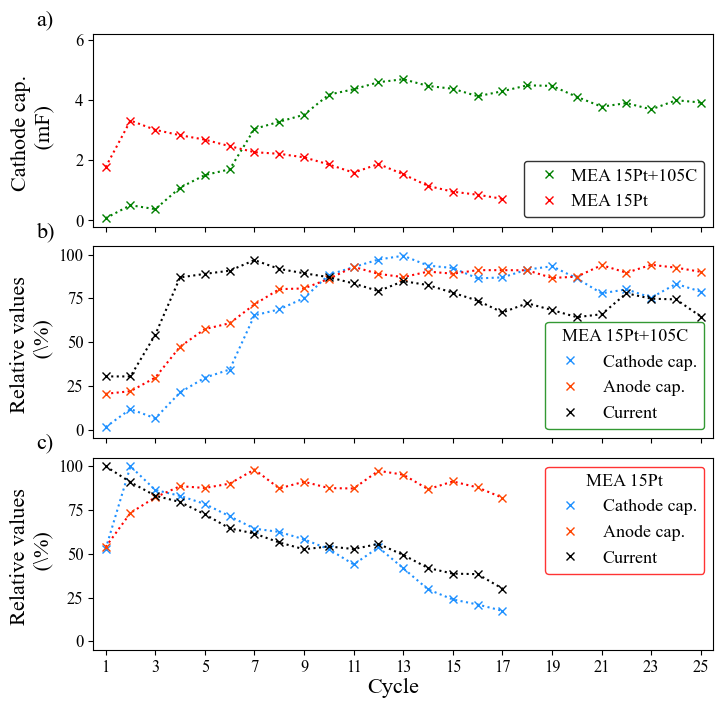

In [29]:
# plt.rcParams['text.usetex'] = True
plt.rcParams['axes.formatter.use_locale'] = True

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": "Times New Roman"
})

s047 = {'name':'047', "loading" : "MEA 15Pt"} # hotovo
s046 = {'name':'046', "loading" : "MEA 15Pt+105C"}   # hotovo

# Create figure and stacked axes
fig, axs = plt.subplots(3, 1, figsize=(8, 8), gridspec_kw={'hspace': 0.1}, sharex = True)  # No space between graphs

MEA = [s046,s047]
we.load_MEA_params(MEA)
color = ['green','red']
for mea in MEA:     
    cmap = plt.get_cmap('rainbow')
    # colors = cmap(np.linspace(0,1,mea['cycles'])) 
    colors = cmap(np.linspace(0,1,15))
    time = []
    for t in range(1,1+mea['cycles']):
        time.append(t)

    Ccavg = np.zeros(mea['cycles'])
    # print(Crel)
    for voltage in range(1,11):
        Ccavg += 1000*mea['Cc'][:,voltage]/4.84
    if mea == s046:
        axs[0].plot(np.array(time),Ccavg/10,'x', label = mea['loading'], c = 'green')
        axs[0].plot(np.array(time),Ccavg/10,':',  c = 'green')
    else:
        axs[0].plot(np.array(time),Ccavg/10,'x', label = mea['loading'], c = 'red')
        axs[0].plot(np.array(time),Ccavg/10,':',  c = 'red')
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].set_ylabel('Cathode cap. \n (mF)', size = 16,labelpad=15)
axs[0].legend(loc = 'lower right', fontsize = 13,edgecolor = 'black',handletextpad = 0.2,bbox_to_anchor = (1.0,0))

axs[0].set_ylim([-0.2,6.2])
# # # # # # # # Závislost na čase v jednom grafu pro různá napětí

for i,mea in enumerate(MEA):     
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0,1,15))
    time = []
    for t in range(1,1+mea['cycles']):
        time.append(t)
    Irel = np.zeros(mea['cycles'])
    Ccrel = np.zeros(mea['cycles'])
    Carel = np.zeros(mea['cycles'])
    # print(Crel)
    for voltage in range(4,11):
        # # print(np.array((mea['Cc'][:,voltage])/max((mea['Cc'][:,voltage]))))
        Ccrel += mea['Cc'][:,voltage]/max(mea['Cc'][:,voltage])
        Carel += mea['Ca'][:,voltage]/max(mea['Ca'][:,voltage])
        Irel += (mea['I'][:,voltage])/max((mea['I'][:,voltage]))

    axs[i+1].plot(np.array(time), 100*Ccrel/7,':', color='dodgerblue')
    axs[i+1].plot(np.array(time), 100*Ccrel/7,'x', label='Cathode cap.', color='dodgerblue')
    
    axs[i+1].plot(np.array(time), 100*Carel/7,':', color='red')
    axs[i+1].plot(np.array(time), 100*Carel/7,'x', label='Anode cap.', color='orangered')
    # axs[i+1].axhline(100)
    axs[i+1].plot(np.array(time), 100*Irel/7, ':', color='black')
    axs[i+1].plot(np.array(time), 100*Irel/7,'x', label='Current', color='black')
    
    axs[i+1].set_ylabel('Relative values \n (\%)',size = 16)
    axs[i+1].legend(fontsize = 13,title = mea['loading'],title_fontsize = 13,edgecolor = color[i])
    # axs[i+1].get_legend().set_title(mea['loading'],title_fontsize = 13)
    axs[i+1].set_ylim([-5,105])
    axs[i+1].set_xlim([0.5,25.5])
    axs[i+1].set_xticks([1,3,5,7,9,11,13,15,17,19,21,23,25])
    axs[i+1].tick_params(axis='both', which='major', labelsize=12)
axs[0].text(-1.8,6.5,'a)',size = 16)
axs[1].text(-1.8,110,'b)',size = 16)
axs[2].text(-1.8,110,'c)',size = 16)
  
# Common x-label for all
fig.supxlabel('Cycle',y=0.05,size = 16)

# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/capacity 046 047.png',dpi = 500, format = 'png', bbox_inches = 'tight')


plt.show()



## Fig. 12

In [27]:
import hybdrt
number = '047'
folder = glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2024_new_naming/'+'*'+number+'*/'))[0]
files =  glob(os.path.join(folder,'*PEIS*'+'*.mpt'))
print(files)
drt = hybdrt.models.DRT()
taus = []
gammas = []
Zs = []
for file in files:
    cycles = [8,23,38]
    try:
        df = we.read_file(file)
        
        for cycle in cycles:
            if 'ay4_procedure2' in file:
                cycle += 1
            f,Z = we.freq_and_Z(df,cycle,f_min = 5)
            # print(f,Z)
            # plt.plot(Z.real,-Z.imag)
            Zs.append(Z)
            drt.fit_eis(f, Z)
            tau = drt.get_tau_eval(20)
            taus.append(tau)
            gamma = drt.predict_drt(tau)
            gammas.append(gamma)
            E,Es = we.data_average(df,'<Ewe>/V',cycle)
            # print(E)
            # plt.plot(tau,gamma)
            # plt.xscale('log')
    except:
        pass

['//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day1_procedure1_05_PEIS.mpt', '//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day2_procedure1_05_PEIS.mpt', '//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day3_procedure1_05_PEIS.mpt', '//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day4_procedure1_05_PEIS.mpt', '//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day4_procedure2_05_PEIS.mpt', '//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day5_procedure1_05_PEIS.mpt', '//ELECTROLYZER/PEM-WE_measurements/2024_new_naming\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\II_Day6_procedure1_05_PEIS.mpt']
Generating impedance integ

C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\hybdrt\models\drt1d.py:986: UserWarning: Solution did not converge within 50 iterations. This is usually not an issue.
  warnings.warn(f'Solution did not converge within {max_iter} iterations. This is usually not an issue.')
C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\hybdrt\models\drt1d.py:986: UserWarning: Solution did not converge within 50 iterations. This is usually not an issue.
  warnings.warn(f'Solution did not converge within {max_iter} iterations. This is usually not an issue.')
C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\hybdrt\models\drt1d.py:986: UserWarning: Solution did not converge within 50 iterations. This is usually not an issue.
  warnings.warn(f'Solution did not converge within {max_iter} iterations. This is usually not an issue.')
C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\hybdrt\models\drt1d.py:986: UserWarning: Solution did not converge within 50 

### Fig. 12 a)

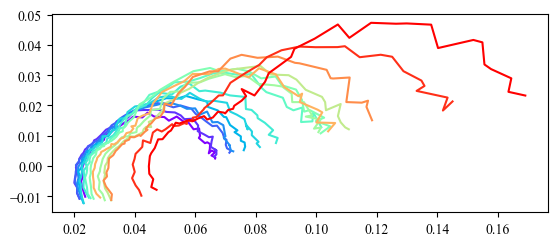

In [31]:
colors = we.get_colors(len(gammas))
for Z,color in zip(Zs,colors):
    plt.plot(Z.real, -Z.imag,c=color)
plt.gca().set_aspect('equal')
plt.show()

### Fig. 12 b)

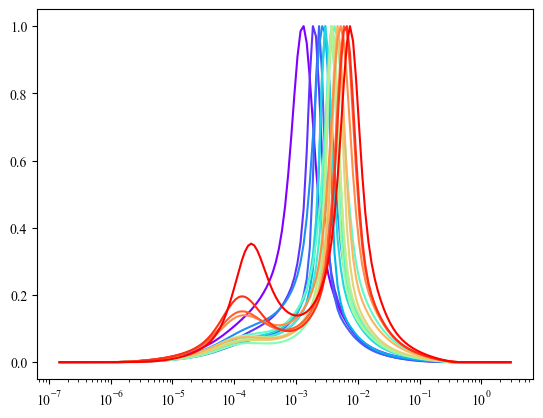

In [24]:
colors = we.get_colors(len(gammas))
for tau, gamma, color in zip(taus, gammas,colors):
    plt.plot(tau, gamma/max(gamma),c=color)
plt.xscale('log')
plt.show()

### Fig. 12c)

['W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_0.txt', 'W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_1.txt', 'W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_2.txt', 'W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_3.txt', 'W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_4.txt', 'W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_5.txt', 'W:\\Pt+C paper\\Data z PEMWE\\047_II_II_Ir etched star, Pt 14 nm no C etched star\\EIS spectra 500 mA\\spectrum_6.txt']
Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\hybdrt\models\drt1d.py:986: UserWarning: Solution did not converge within 50 iterations. This is usually not an issue.
  warnings.warn(f'Solution did not converge within {max_iter} iterations. This is usually not an issue.')
C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\hybdrt\models\drt1d.py:986: UserWarning: Solution did not converge within 50 iterations. This is usually not an issue.
  warnings.warn(f'Solution did not converge within {max_iter} iterations. This is usually not an issue.')


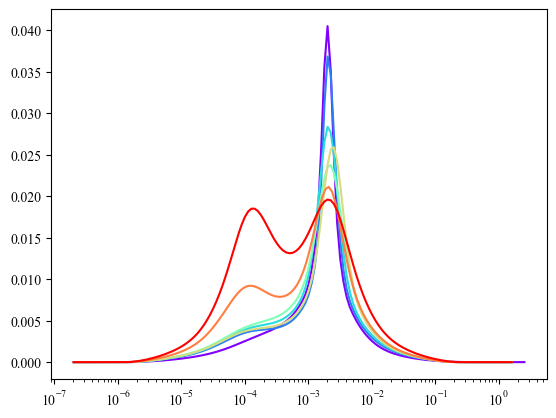

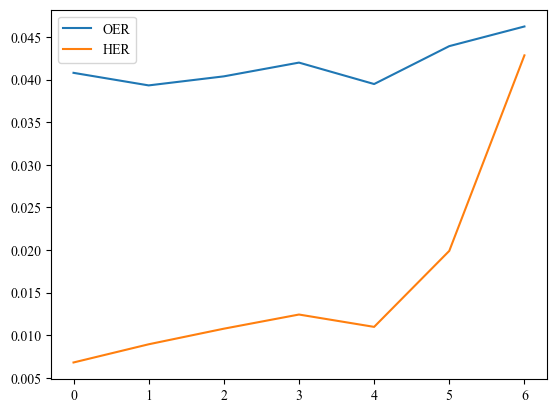

In [26]:
import hybdrt
from bayes_drt2.inversion import Inverter

# file = r"W:\Pt+C paper\Data z PEMWE\047_II_II_Ir etched star, Pt 14 nm no C etched star\EIS spectra 500 mA.txt"
folder = r"W:\Pt+C paper\Data z PEMWE\047_II_II_Ir etched star, Pt 14 nm no C etched star\EIS spectra 500 mA"
files =  glob(os.path.join(folder,'*'))
print(files)

# inv = Inverter()
drt = hybdrt.models.DRT()
taus = []
gammas = []
Zs = []

colors = we.get_colors(len(files))
for color,file in zip(colors,files):
    data = np.loadtxt(file, skiprows = 4)
    Z = data[:,1] + 1j*data[:,2]
    # print(Z)
    f = data[:,0]
    Z = Z[0:-2]
    f = f[0:-2]
    Zs.append(Z)
    drt.fit_eis(f,Z)

    tau = drt.get_tau_eval(20)
    taus.append(tau)
    gamma = drt.predict_drt(tau)
    gammas.append(gamma)
    # print(drt.quantify_peaks())

    # inv.fit(f, Z, mode='optimize',nonneg = True,outliers = True,warmup=100, samples=100,init_from_ridge = True)  # initialize from ridge solution
    #     # inv_map.fit_peaks(prom_rthresh=0.05)
    # gammas.append(inv.final_gamma)
    # taus.append(inv.tau_plot)

for tau, gamma, color in zip(taus, gammas,colors):
    plt.plot(tau, gamma,c=color)
plt.xscale('log')
plt.show()

fit_params = np.loadtxt(r"W:\Pt+C paper\Data z PEMWE\047_II_II_Ir etched star, Pt 14 nm no C etched star\fit_params.txt", skiprows = 2)
plt.plot(fit_params[:,3],label = 'OER')
plt.plot(fit_params[:,1],label = 'HER')
plt.legend()
plt.show()

### Fig. 12d)

['W:\\Pt+C paper\\Data z PEMWE\\046_IV_IV_Ir etched star, Pt 14 nm + C 102 nm etched star\\EIS spectra 380 mA\\spectrum_0.txt', 'W:\\Pt+C paper\\Data z PEMWE\\046_IV_IV_Ir etched star, Pt 14 nm + C 102 nm etched star\\EIS spectra 380 mA\\spectrum_1.txt']
Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


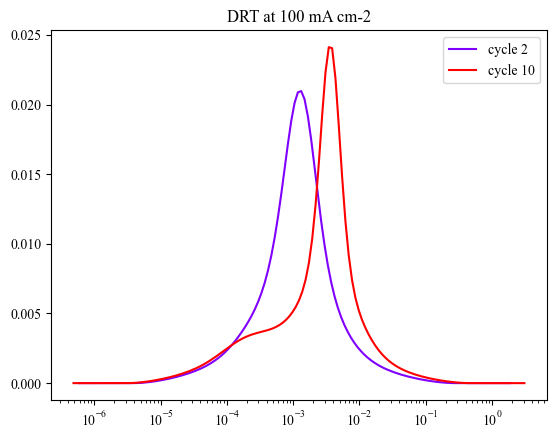

In [40]:

# file = r"W:\Pt+C paper\Data z PEMWE\047_II_II_Ir etched star, Pt 14 nm no C etched star\EIS spectra 500 mA.txt"
folder = r"W:\Pt+C paper\Data z PEMWE\046_IV_IV_Ir etched star, Pt 14 nm + C 102 nm etched star\EIS spectra 380 mA/"
files =  glob(os.path.join(folder,'*spectrum*'))
print(files)

# inv = Inverter()
drt = hybdrt.models.DRT()
taus = []
gammas = []
Zs = []

colors = we.get_colors(len(files))
for color,file in zip(colors,files):
    data = np.loadtxt(file, skiprows = 4)
    Z = data[:,1] + 1j*data[:,2]
    # print(Z)
    f = data[:,0]
    Z = Z[0:-4]
    f = f[0:-4]
    Zs.append(Z)
    drt.fit_eis(f,Z)

    tau = drt.get_tau_eval(20)
    taus.append(tau)
    gamma = drt.predict_drt(tau)
    gammas.append(gamma)

for tau, gamma, color, label in zip(taus, gammas,colors, ['cycle 2', 'cycle 10']):
    plt.plot(tau, gamma,c=color, label = label)
plt.title('DRT at 100 mA cm-2')
plt.legend()
plt.xscale('log')
plt.show()


## Fig. 13

### Fig. 13a

25
17


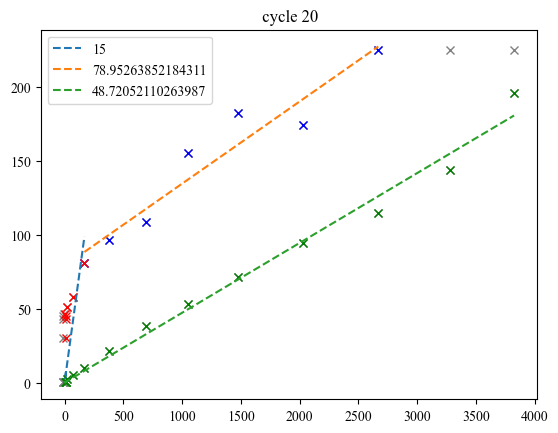

In [42]:

def linear_func(x,a,b):
    return a*x+b
# 
def linear_fit(x, k):
    return k*x

# *****************************************************************

cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,16))
s047 = {'name' : '047','loading' : 15}
s046 = {'name' : '046','loading' : 15}
s028 = {'name' : '028'}

MEA = [s046,s047]
we.load_MEA_params(MEA)
cycle_plot = 19

for mea in MEA:
    ta = []
    tc1 = []
    tc2 = []
    t = []
    k1 = []
    k2 = []
    q2 = []
    folder_path =  glob(os.path.join('C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'+mea['name']+'*/PEIS'))[0]
    ignore_files = glob(os.path.join(folder_path,'nefitovat*'))
    ignore_c2 = np.loadtxt(ignore_files[2],skiprows=0)
    ignore_c1 = np.loadtxt(ignore_files[1],skiprows=0)
    ignore_a = np.loadtxt(ignore_files[0],skiprows=0)

    for cycle in range(0,mea["cycles"]):
        Ic2 = mea['I'][cycle]
        Ic1 = abs(mea['I'][cycle])
        Ia = abs(mea['I'][cycle])
        U_corr = mea['U'][cycle]-mea['I'][cycle]*mea['Ro'][cycle,:]/1000

        yc2 = 1/mea['Rc'][cycle,:]
        yc1 = 1/mea['Rc'][cycle,:]
        ya = 1/mea['Ra'][cycle,:]

        ignore_index_c2 = [0,1,2,3,4,5]
        ignore_index_c1 = [14,13,12,11,10,9,8,7]
        ignore_index_a = []
        for row,cycle_to_ignore in enumerate(ignore_c2[:,0]):
            if int(cycle_to_ignore-1) == cycle:
                ignore_index_c2.append(int(ignore_c2[row,1]))
                
        for row,cycle_to_ignore in enumerate(ignore_c1[:,0]):
            if int(cycle_to_ignore-1) == cycle:
                ignore_index_c1.append(int(ignore_c1[row,1]))
                
        for row,cycle_to_ignore in enumerate(ignore_a[:,0]):
            if int(cycle_to_ignore-1) == cycle:
                ignore_index_a.append(int(ignore_a[row,1]))

        Ic2 = np.delete(Ic2, ignore_index_c2)
        yc2 = np.delete(yc2, ignore_index_c2)
        
        Ic1 = np.delete(Ic1, ignore_index_c1)
        yc1 = np.delete(yc1, ignore_index_c1)
        
        Ia = np.delete(Ia, ignore_index_a)
        ya = np.delete(ya, ignore_index_a)
        if mea == s046 and cycle == cycle_plot:
            plt.plot(mea['I'][cycle],1/mea['Rc'][cycle],"x", c='grey')
            plt.plot(Ic2,yc2,"x",c='blue')
            plt.plot(Ic1,yc1,"x",c='red')

        params, covariance = curve_fit(
                    linear_fit,Ic1,yc1)
        
        k = params[0]
        tc1.append(2.3/k)
        k1.append(k)
        if mea == s046 and cycle == cycle_plot:
            plt.plot(Ic1,k*Ic1,"--", label = mea['loading'])

        params, covariance = curve_fit(
                    linear_func,Ic2,yc2)
        k = params[0]
        q = params[1]
        tc2.append(2.3/k)
        k2.append(k)
        q2.append(q)
        if mea == s046 and cycle == cycle_plot:
            plt.plot(Ic2,k*Ic2+q,"--", label = q)
            plt.plot(mea['I'][cycle],1/mea['Ra'][cycle],"x", c='grey')
            plt.plot(Ia,ya,"x",c='green')
# 
        # print(q)
        params, covariance = curve_fit(
                    linear_fit,Ia,ya)
        k = params[0]
        ta.append(2.3/k)
        if mea == s046 and cycle == cycle_plot:
            plt.plot(Ia,k*Ia,"--", label = 2.3/k)
            plt.legend()
            plt.title(' cycle ' + str(cycle+1))
            # # plt.savefig("C:/Users/Herman/Desktop/Elektrolyzéry výzkum/Článek/grafy/"+str(co)+' cycle '+str(cycle+1)+'.png',dpi = 300, format = 'png', bbox_inches = 'tight')
            plt.show()
    mea['ta'] = np.array(ta)
    mea['tc1'] = np.array(tc1)
    mea['tc2'] = np.array(tc2)
    # mea['tj'] = np.array(t)
    mea['k1'] = np.array(k1)
    mea['k2'] = np.array(k2)
    mea['q2'] = np.array(q2)

### Fig. 13b

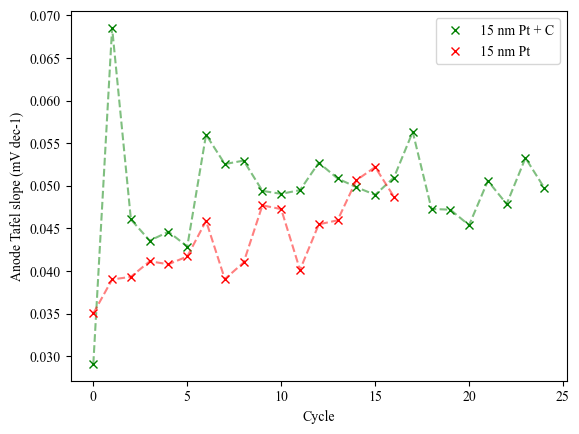

In [43]:
s046['label'] = "15 nm Pt + C"
s047['label'] = "15 nm Pt"
s046['color'] = 'green'
s047['color'] = 'red'
for mea in [s046,s047]:
    plt.plot(2.3/mea['ta'], 'x',label = mea['label'], c = mea['color'])
    plt.plot(2.3/mea['ta'], '--', c = mea['color'],alpha = 0.5)
    
plt.legend()
plt.xlabel('Cycle')
plt.ylabel('Anode Tafel slope (mV dec-1)')
plt.show()

### Fig. 13c

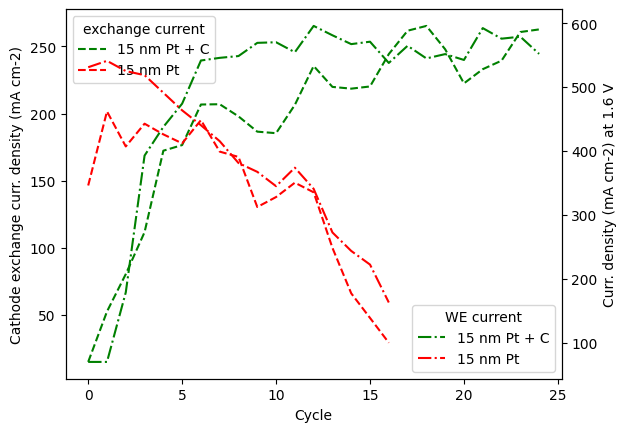

In [26]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

for mea in [s046,s047]:
    ax1.plot(mea['q2']*353*8.31/96.500/2/4.84, '--',label = mea['label'], c = mea['color'])
    # ax1.plot(mea['q2']*353*8.31/96.500/2/4.84, '--', c = mea['color'],alpha = 0.5)
    ax2.plot(mea['I'][:,12]/4.84, '-.', c = mea['color'],label = mea['label'])
    
# plt.legend()
ax1.set_xlabel('Cycle')
ax1.set_ylabel('Cathode exchange curr. density (mA cm-2)')
ax2.set_ylabel('Curr. density (mA cm-2) at 1.6 V')
ax1.legend(title = 'exchange current')
ax2.legend(title = 'WE current')

plt.show()

## Fig. 14

### Fig. 14a)

15
21
21
25
45
25
13
[0.10036661]
[0.0810485]
[0.12202538]
[0.08302042]
[0.13318624]
[0.19315466]
[0.08785714]


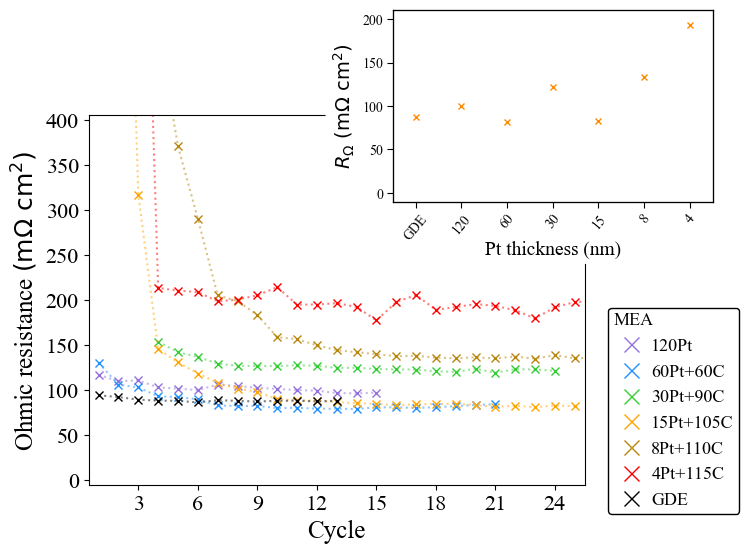

In [48]:

s028 = {'name':'028', "loading" : "emph{MEA GDE}", "offset" : 0} # hotovo
s029 = {'name':'029', "loading" : "emph{MEA 120Pt}", "offset" : 0} # hotovo
s041 = {'name':'041', "loading" : "emph{MEA 60Pt+60C}", "offset" : 0} # hotovo
s042 = {'name':'042', "loading" : "emph{MEA 30Pt+120C}", "offset" : 3} # hotovo
s046 = {'name':'046', "loading" : "emph{MEA 15Pt+105C}","offset" : 0}   # hotovo
s049 = {'name':'049', "loading" : "emph{MEA 8Pt+110C}","offset" : 2} # hotovo
s050 = {'name':'050', "loading" : "emph{MEA 4Pt+115C}", "offset" : 1} # hotovo, možná by se dal dofitovat 1. cyklus


MEA = [s029,s041,s042,s046,s049,s050,s028]

labels = ['120Pt','60Pt+60C','30Pt+90C','15Pt+105C','8Pt+110C','4Pt+115C','GDE']
colors = [   'mediumpurple','dodgerblue','limegreen','orange' , 'darkgoldenrod','red','black']

Ro_vs_loading = [87.85714,100.36661,081.0485,121.89631,83.02042,133.18624,193.15466]


we.load_MEA_params(MEA)
for i,mea in enumerate(MEA):     

    time = []
    for t in range(0,mea['cycles']):
        time.append(t)

    # print(Crel)
    avg_param = np.zeros(mea['cycles'])
    for voltage in range(1,15):
        avg_param += mea['Ro'][:,voltage]/14
        # plt.plot(np.array(time),(np.array((mea['Ro'][:,voltage]))),  color = colors[voltage])
        # except:
    if mea['name']=="028":
        plt.plot(np.array(time)+1,1000*avg_param*4.84,'x', label = labels[i],c ='black')
        plt.plot(np.array(time)+1,1000*avg_param*4.84,':',c ='black',alpha = 0.5)
    else:
        plt.plot(np.array(time)+mea['offset']+1,1000*avg_param*4.84,'x', label = labels[i],c = colors[i])
        plt.plot(np.array(time)+mea['offset']+1,1000*avg_param*4.84,':',c =colors[i],alpha = 0.5)
    avg_fit = np.polyfit(time[-10:],avg_param[-10:],0)
    # plt.axhline(avg_fit)
    print(avg_fit*4.84)

plt.legend(title = 'MEA',loc='center right', bbox_to_anchor=(1.33, 0.2),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

plt.ylim(-5,405)   
plt.ylabel(r'Ohmic resistance $\mathrm{ \left(m \Omega ~ cm^{2} \right) }$',size=18)
plt.xlabel("Cycle",size=18) 
xticks = np.arange(0, 28, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
plt.xticks(xticks, xlabels,size = 16)
plt.xlim(0.5,25.5)
plt.yticks(size = 16)
 
inset_ax = plt.axes([0.6, 0.7, 0.5, 0.4])  # [x, y, width, height] in figure coordinates
inset_ax.plot( [1,2,3,4,5,6,7],Ro_vs_loading ,'x',markersize = 5, color='darkorange')
# inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,':', color='darkorange',alpha = 0.5)
inset_ax.set_xlabel("Pt thickness (nm)",size = 14,y=2,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.xaxis.set_label_coords(0.5, -0.2)
inset_ax.set_ylabel(r'$R_{\Omega} ~ \mathrm{ \left(m \Omega ~ cm^{2} \right) }$',size=14,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.set_xticks([1,2,3,4,5,6,7],['GDE',120,60,30,15,8,4],rotation = 50)
# inset_ax.tick_params(axis='both', labelsize=12) 
for label in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=1.5'))

inset_ax.set_xlim(0.5,7.5)
inset_ax.set_ylim(-10,211)

inset_axx = inset_ax.twinx()    
inset_axx.set_ylim(-10,211)
inset_axx.set_yticks([0,50,100,150,200],['','','','',''])
inset_axx.tick_params('y',size = 4,left = True, right = False)

inset_axy = inset_ax.twiny()    
inset_axy.set_xlim(0.5,7.5)
inset_axy.set_xticks([1,2,3,4,5,6,7],['','','','','','',''])
inset_axy.tick_params('x',size = 4,bottom = True, top = False)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/high_thickness_series_Ri_in_time.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()

### Fig. 14b)

<>:22: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:22: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Herman\AppData\Local\Temp\ipykernel_29508\1132732446.py:22: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.22),


15
21
21
25
45
25
[12.70867755]
[8.37178969]
[6.08717248]
[4.25610569]
[1.8054172]
[0.32733187]


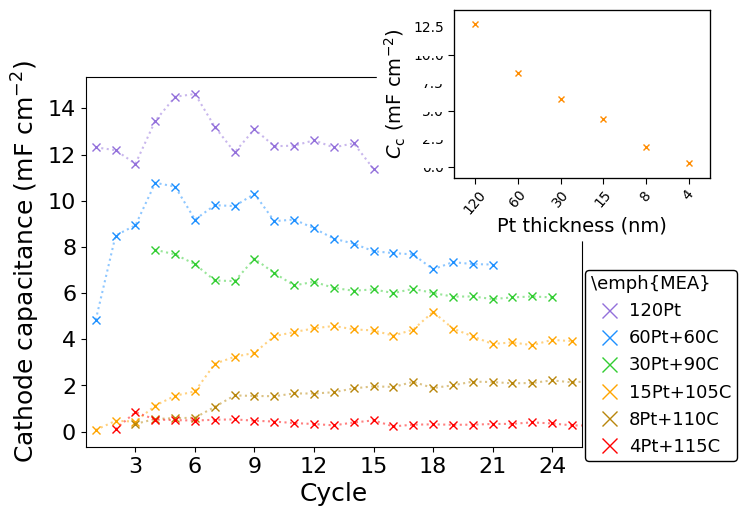

In [3]:
MEA = [s029,s041,s042,s046,s049,s050]
Cc_vs_loading = [12.7,8.37,6.08,4.25,1.8,0.32]

labels = ['120Pt','60Pt+60C','30Pt+90C','15Pt+105C','8Pt+110C','4Pt+115C','GDE']
colors = [   'mediumpurple','dodgerblue','limegreen','orange' , 'darkgoldenrod','red','black']

we.eis.load_MEA_params(MEA)
for i,mea in enumerate(MEA):     

    time = []
    for t in range(0,mea['cycles']):
        time.append(t)
    avg_param = np.zeros(mea['cycles'])
    for voltage in range(0,10):
        avg_param += mea['Cc'][:,voltage]/10
    plt.plot(np.array(time)+mea['offset']+1,1000*avg_param/4.84,'x', label = labels[i],c = colors[i])
    plt.plot(np.array(time)+mea['offset']+1,1000*avg_param/4.84,':',c =colors[i],alpha = 0.5)
    avg_fit = np.polyfit(time[-15:],avg_param[-15:],0)

    print(1000*avg_fit/4.84)

plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.22),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
 
plt.ylabel(r'Cathode capacitance $\mathrm{ \left(m F ~ cm^{-2} \right) }$',size=18)
plt.xlabel("Cycle",size=18) 
xticks = np.arange(0, 28, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
plt.xticks(xticks, xlabels,size = 16)
plt.xlim(0.5,25.5)
plt.yticks(size = 16)

inset_ax = plt.axes([0.7, 0.67, 0.4, 0.35])  # [x, y, width, height] in figure coordinates
inset_ax.plot(  [1,2,3,4,5,6],Cc_vs_loading ,'x',markersize = 5, color='darkorange')

# inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,':', color='darkorange',alpha = 0.5)
inset_ax.set_xlabel("Pt thickness (nm)",size = 14,y=0.5,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.xaxis.set_label_coords(0.5, -0.23)


for label in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=1.5'))

inset_ax.set_ylabel(r'$C_{\mathrm{c}} ~ \mathrm{ \left(mF ~ cm^{-2} \right) }$',size=14,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.set_xticks([1,2,3,4,5,6],[120,60,30,15,8,4],rotation = 50)

# inset_ax.tick_params(axis='both', labelsize=12) 
inset_ax.set_xlim(0.5,6.5)
inset_ax.set_ylim(-1,14)

inset_axx = inset_ax.twinx()    
inset_axx.set_ylim(-1,14)
inset_axx.set_yticks([0,5,10],['','',''])
inset_axx.tick_params('y',size = 4,left = True, right = False)

inset_axy = inset_ax.twiny()    
inset_axy.set_xlim(0.5,6.5)
inset_axy.set_xticks([1,2,3,4,5,6],['','','','','',''])
inset_axy.tick_params('x',size = 4,bottom = True, top = False)

# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/high_thickness_series_Cc_in_time.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()

### Fig. 14c)

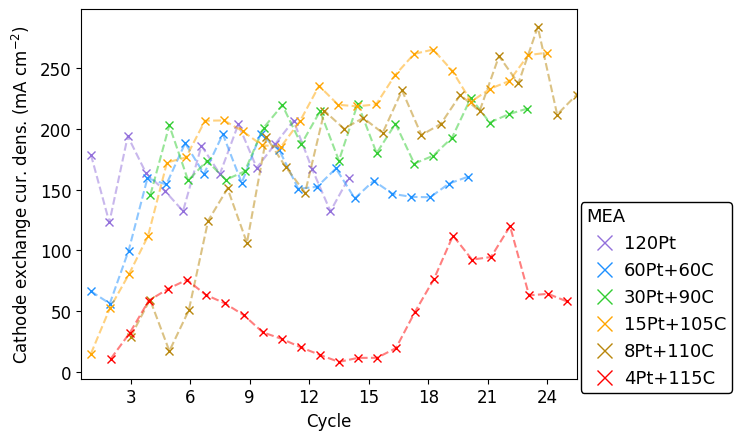

In [4]:

labels = ['120Pt','60Pt+60C','30Pt+90C','15Pt+105C','8Pt+110C','4Pt+115C','GDE']
colors = [   'mediumpurple','dodgerblue','limegreen','orange' , 'darkgoldenrod','red','black']

for i,mea in enumerate(MEA): 
    Rc = np.loadtxt(r"W:\Pt+C paper\Data z PEMWE\exchange current density\exchange current density"+mea['name']+".txt")
    time = np.linspace(1,len(Rc)-1,len(Rc))+mea['offset']
    plt.plot(time,Rc*353*8.31/96.500/2/4.84,'x',c=colors[i], label = labels[i])
    plt.plot(time,Rc*353*8.31/96.500/2/4.84,'--',c=colors[i],alpha = 0.5)
plt.xlim(0,20)
plt.legend(title = 'MEA',loc='center right', bbox_to_anchor=(1.33, 0.22),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
 
plt.ylabel(r'Cathode exchange cur. dens. $\mathrm{ \left(m A ~ cm^{-2} \right) }$',size=12)
plt.xlabel("Cycle",size=12) 
xticks = np.arange(0, 28, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
plt.xticks(xticks, xlabels,size = 12)
plt.xlim(0.5,25.5)
plt.yticks(size = 12)
plt.show()

## Fig. 16

In [50]:
s028 = {'name':'028', "loading" : "emph{MEA GDE}", "offset" : 0} # hotovo
s049 = {'name':'049', "loading" : "7 nm Pt +  110 nm C", "offset" : 2} # hotovo
s055 = {'name':'055', "loading" : "7 nm Pt +  58 nm C", "offset" : 0} # hotovo
s065 = {'name':'065', "loading" : "7 nm Pt +  29 nm C", "offset" : 0} # hotovo
s094 = {'name':'094', "loading" : "7 nm Pt + 7 nm C",  "offset" : 0} # hotovo
s098 = {'name':'098', "loading" : "7 nm Pt", "offset" : 0} # hotovo
s120 = {'name':'120', "loading" : "7 nm Pt + 15 nm C", "offset" : 0}


Ro_vs_loading = [87.8571424,133.18623999,98.8459543,108.40483091,100.53689717,126.11213232,189.24900819]
MEA = [s028,s049,s055,s065,s120,s094,s098]

labels = ['emph{GDE}','emph{8Pt+110C}','emph{8Pt+60C}','emph{8Pt+30C}','emph{8Pt+15C}','emph{8Pt+8C}','emph{8Pt}','emph{GDE}']
colors = [   'mediumpurple','dodgerblue','limegreen','orange' , 'darkgoldenrod','red',]


load_MEA_params(MEA)
for i,mea in enumerate(MEA):     

    time = []
    for t in range(0,mea['cycles']):
        time.append(t)

    avg_param = np.zeros(mea['cycles'])
    for voltage in range(1,15):
        avg_param += mea['Ro'][:,voltage]/14
        # plt.plot(np.array(time),(np.array((mea['Ro'][:,voltage]))),  color = colors[voltage])
        # except:
    if mea['name']=="028":
        plt.plot(np.array(time)+1,1000*avg_param*4.84,'x', label = labels[i],c ='black')
        plt.plot(np.array(time)+1,1000*avg_param*4.84,':',c ='black',alpha = 0.5)
    else:
        plt.plot(np.array(time)+mea['offset']+1,1000*avg_param*4.84,'x', label = labels[i],c = colors[i-1])
        plt.plot(np.array(time)+mea['offset']+1,1000*avg_param*4.84,':',c =colors[i-1],alpha = 0.5)
    avg_fit = np.polyfit(time[-10:],avg_param[-10:],0)
    # plt.axhline(avg_fit)
    print(1000*avg_fit*4.84)

plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.215),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

plt.ylim(-5,405)   
plt.ylabel(r'Ohmic resistance $\mathrm{ \left(m \Omega ~ cm^{2} \right) }$',size=18)
plt.xlabel("Cycle",size=18) 
xticks = np.arange(0, 28, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
plt.xticks(xticks, xlabels,size = 16)
plt.xlim(0.5,25.5)
plt.yticks(size = 16)
    
inset_ax = plt.axes([0.68, 0.7, 0.35, 0.35])  # [x, y, width, height] in figure coordinates
inset_ax.plot( [1,2,3,4,5,6,7],Ro_vs_loading ,'x',markersize = 5, color='darkorange')
# inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,':', color='darkorange',alpha = 0.5)
inset_ax.set_xlabel("C thickness (nm)",size = 14,y=0.0,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.set_ylabel(r'$R_{\Omega} ~ \mathrm{ \left(m \Omega ~ cm^{2} \right) }$',size=14,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.xaxis.set_label_coords(0.5, -0.27)

inset_ax.set_xticks([1,2,3,4,5,6,7],['GDE',110,60,30,15,8,0],rotation = 50,size = 10)

for label in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.8'))

inset_ax.set_xlim(0.5,7.5)
inset_ax.set_ylim(-10,211)

inset_axx = inset_ax.twinx()    
inset_axx.set_ylim(-10,211)
inset_axx.set_yticks([0,50,100,150,200],['','','','',''])
inset_axx.tick_params('y',size = 4,left = True, right = False)

inset_axy = inset_ax.twiny()    
inset_axy.set_xlim(0.5,7.5)
inset_axy.set_xticks([1,2,3,4,5,6,7],['','','','','','',''])
inset_axy.tick_params('x',size = 4,bottom = True, top = False,labelsize = 10)

# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/8Pt+xC_ohmic_resistance_in_time.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

<>:39: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:39: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Herman\AppData\Local\Temp\ipykernel_26076\3691569466.py:39: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.215),
C:\Users\Herman\AppData\Local\Temp\ipykernel_26076\3691569466.py:39: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.215),


NameError: name 'load_MEA_params' is not defined

## Fig. 17

<>:33: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:33: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Herman\AppData\Local\Temp\ipykernel_39244\3839555139.py:33: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.75),


45
18
19
54
19
15


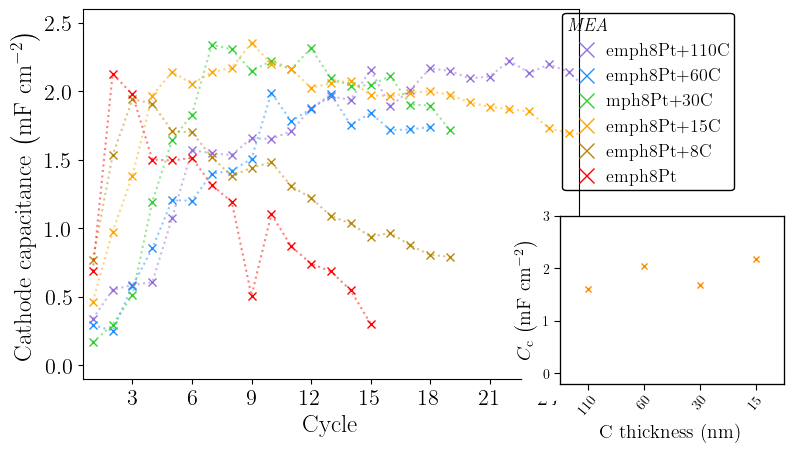

In [18]:
s049 = {'name':'049', "loading" : "7 nm Pt +  110 nm C"} # hotovo
s055 = {'name':'055', "loading" : "7 nm Pt +  58 nm C"} # hotovo
s065 = {'name':'065', "loading" : "7 nm Pt +  29 nm C"} # hotovo
s094 = {'name':'094', "loading" : "7 nm Pt + 7 nm C", "position" : "3-??"} # hotovo
s098 = {'name':'098', "loading" : "7 nm Pt", "position" : "2-2-PS"} # hotovo
s120 = {'name':'120', "loading" : "7 nm Pt + 15 nm C", "position" : "4-1-?"}

MEA = [s049,s055,s065,s120,s094,s098]

labels = ['8Pt+110C','8Pt+60C','8Pt+30C','8Pt+15C','8Pt+8C','8Pt','GDE']
colors = [   'mediumpurple','dodgerblue','limegreen','orange' , 'darkgoldenrod','red',]
Cc_vs_loading = [1.598,2.04497,1.6815,2.17576] # ,1.13197,1.07597

load_MEA_params(MEA)
for i,mea in enumerate(MEA):     

    time = []
    for t in range(0,mea['cycles']):
        time.append(t)

    avg_param = np.zeros(mea['cycles'])
    for voltage in range(0,10):

        avg_param += mea['Cc'][:,voltage]/10

    plt.plot(np.array(time)+1,1000*avg_param/4.84,'x', label = labels[i],c = colors[i])
    plt.plot(np.array(time)+1,1000*avg_param/4.84,':',c =colors[i],alpha = 0.5)
    if mea['name'] == "120":
        avg_fit = np.polyfit(time[-40:-30],avg_param[-40:-30],0)
    else:
        avg_fit = np.polyfit(time[-10:],avg_param[-10:],0)

plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.75),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

plt.ylim(-0.1,2.6)   
plt.ylabel(r'Cathode capacitance $\mathrm{ \left(m F ~ cm^{-2} \right) }$',size=18)
plt.xlabel("Cycle",size=18) 
xticks = np.arange(0, 28, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
plt.xticks(xticks, xlabels,size = 16)
plt.xlim(0.5,25.5)
plt.yticks(size = 16)
    
inset_ax = plt.axes([0.87, 0.10, 0.35, 0.35])  # [x, y, width, height] in figure coordinates
inset_ax.plot( [1,2,3,4],Cc_vs_loading ,'x',markersize = 5, color='darkorange')
# inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,':', color='darkorange',alpha = 0.5)
inset_ax.set_xlabel("C thickness (nm)",size = 14,y=0.5)
# inset_ax.xaxis.set_label_coords(0.5, -0.4)
inset_ax.set_xticks([1,2,3,4],[110,60,30,15],rotation = 50)
# inset_ax.tick_params(axis='both', labelsize=12) 
inset_ax.set_xlim(0.5,4.5)
inset_ax.set_ylim(-0.2,3)

for label in inset_ax.get_xticklabels() + inset_ax.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=1.5'))
    
inset_ax.set_ylabel(r'$C_{\mathrm{c}} ~ \mathrm{ \left(mF ~ cm^{-2} \right) }$',size=14,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))
inset_ax.set_xlabel("C thickness (nm)",size = 14,y=0.5,bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

inset_axx = inset_ax.twinx()    
inset_axx.set_ylim(-0.2,3)
inset_axx.set_yticks([0,1,2,3],['','','',''])
inset_axx.tick_params('y',size = 4,left = True, right = False)

inset_axy = inset_ax.twiny()    
inset_axy.set_xlim(0.5,4.5)
inset_axy.set_xticks([1,2,3,4],['','','',''])
inset_axy.tick_params('x',size = 4,bottom = True, top = False)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/8Pt+xC_cathode_capacitance.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

## Fig. 18

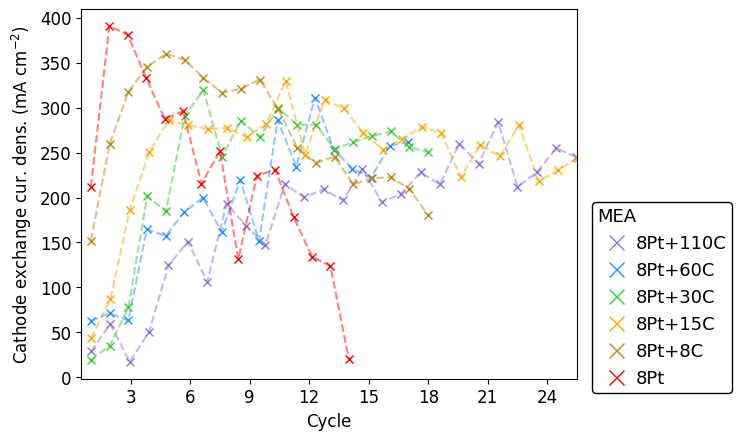

In [29]:
s049 = {'name':'049', "loading" : "7 nm Pt +  110 nm C"} # hotovo
s055 = {'name':'055', "loading" : "7 nm Pt +  58 nm C"} # hotovo
s065 = {'name':'065', "loading" : "7 nm Pt +  29 nm C"} # hotovo
s094 = {'name':'094', "loading" : "7 nm Pt + 7 nm C", "position" : "3-??"} # hotovo
s098 = {'name':'098', "loading" : "7 nm Pt", "position" : "2-2-PS"} # hotovo
s120 = {'name':'120', "loading" : "7 nm Pt + 15 nm C", "position" : "4-1-?"}

MEA = [s049,s055,s065,s120,s094,s098]
labels = ['8Pt+110C','8Pt+60C','8Pt+30C','8Pt+15C','8Pt+8C','8Pt']
colors = [   'mediumpurple','dodgerblue','limegreen','orange' , 'darkgoldenrod','red',]

for i,mea in enumerate(MEA): 
    Rc = np.loadtxt(r"W:\Pt+C paper\Data z PEMWE\exchange current density\exchange current density"+mea['name']+".txt")
    time = np.linspace(1,len(Rc)-1,len(Rc))
    plt.plot(time,Rc*353*8.31/96.500/2/4.84,'x',c=colors[i], label = labels[i])
    plt.plot(time,Rc*353*8.31/96.500/2/4.84,'--',c=colors[i],alpha = 0.5)
plt.xlim(0,20)
plt.legend(title = 'MEA',loc='center right', bbox_to_anchor=(1.33, 0.22),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
 
plt.ylabel(r'Cathode exchange cur. dens. $\mathrm{ \left(m A ~ cm^{-2} \right) }$',size=12)
plt.xlabel("Cycle",size=12) 
xticks = np.arange(0, 28, 3)  # Every third tick15
xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
plt.xticks(xticks, xlabels,size = 12)
plt.xlim(0.5,25.5)
plt.yticks(size = 12)
plt.show()

## Other figures

### time_stabilty_046_047_034_041

### time_stabilty_046_047_034_041

### time_stabilty_046_047_034_041

### time_stabilty_046_047_034_041

### time_stabilty_046_047_034_041

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0
0
0
0


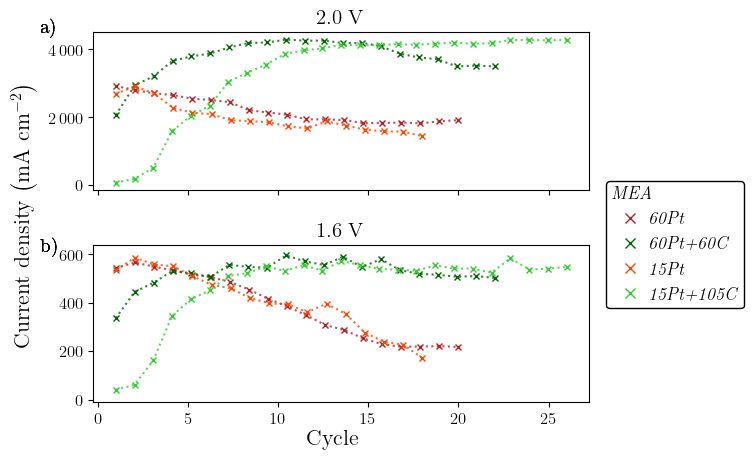

In [23]:
MEA = [s034,s041,s047,s046]

labels = ['120','60','30','15','8','4','GDE']
# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['firebrick','darkgreen' ,'orangered','limegreen']

# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
fig, (ax1, ax2) = plt.subplots(2,1,sharex = True,gridspec_kw={'hspace': 0.35},)


voltage = [2,1.6]
for mea in MEA:
    mea['iatu'] = [[],[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)
                
                # print(index)
                # Iatu.append()
                # plt.plot(I[index],U[index],'x')
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        if uc == 0:
            print(uc)
            ax1.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = mea['label'],c=colors[index])
            ax1.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
            ax1.text(-3.2,4500,'a)',size = 14)
        else:
            # print(uc,mea['iatu'][uc])
            ax2.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = mea['label'],c=colors[index])
            ax2.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
            ax2.set_ylim(-10,640)
            ax2.text(-3.2,610,'b)',size = 14)

    plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 1),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.4,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')


    
fig.supylabel(r'Current density $\mathrm{\left( mA ~ cm^{-2} \right) }$',size=16,x=-0.005)
fig.supxlabel('Cycle',size=16)
ax1.yaxis.set_major_formatter(FuncFormatter(custom_format))
ax1.set_title('2.0 V',size=15)
ax2.set_title('1.6 V',size=15)
ax1.tick_params(axis='both',labelsize = 12)
ax2.tick_params(axis='both',labelsize = 12)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/stability_PtxPt+C.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()

### MEA 034,041,029,028

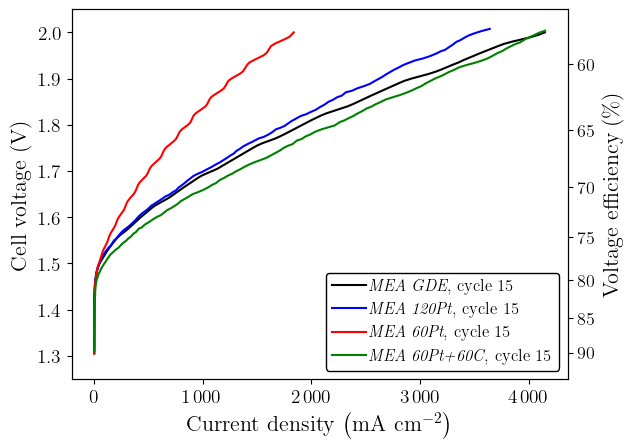

In [26]:
MEA = [s034,s041,s029,s028]
# labels = ["\emph{MEA 480 $\mu$g plain}","\emph{MEA 480 $\mu$g}","\emph{MEA GDE}","\emph{MEA 240 $\mu$g}"]

cmap = plt.get_cmap('rainbow')
colors = ['red','blue','black','green']


for mea in MEA:
    # folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*')  
    mea['files'] = glob(os.path.join('C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'+mea['name']+'*/SV',mea['name']+'_cycle_rising*'+'*.txt'))
MEA = [s028,s029,s034,s041]
s034['color'] = 'red'
s041['color'] = 'green'
s028['color'] = 'black'
s029['color'] = 'blue'
for mea in MEA:
    d = np.loadtxt(mea['files'][14],skiprows=1) 
    I = d[:,0] 
    U = d[:,1] 
    plt.plot(I/4.84,U,'-',label = mea['loading']+', cycle 15',c=mea['color'])  

plt.ylim(1.25,2.05)     
# plt.annotate("", xytext=(3000, 2.05), xy=(4000, 2.05), arrowprops=dict(arrowstyle="->"))
# plt.annotate("", xytext=(2800, 2.05), xy=(1800, 2.05), arrowprops=dict(arrowstyle="->"))
plt.legend(loc='lower right',handletextpad=0.2,fontsize=12,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.ylabel('Cell voltage (V)',size=16)
plt.xlabel(r'Current density $\mathrm{\left( mA ~ cm^{-2} \right) }$',size=16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.gca().xaxis.set_major_formatter(FuncFormatter(custom_format))
right_ax = plt.gca().twinx()
right_ax.set_ylim(1.25,2.09)
right_ax.set_yticks([1.31,1.388,1.475,1.573,1.686,1.815,1.966])
right_ax.set_yticklabels(['90','85','80','75','70','65','60'])

# Optional styling
right_ax.tick_params(axis='y', direction='out', top=True,labeltop = True,labelsize = 13)
right_ax.set_ylabel('Voltage efficiency (\%)',size = 16,labelpad = 5)
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/IV,58Pt,58PtC,GDE,116Pt.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()      



### high_C_loading_series

029 0
041 1
042 2
046 3
049 4
050 5
028 6


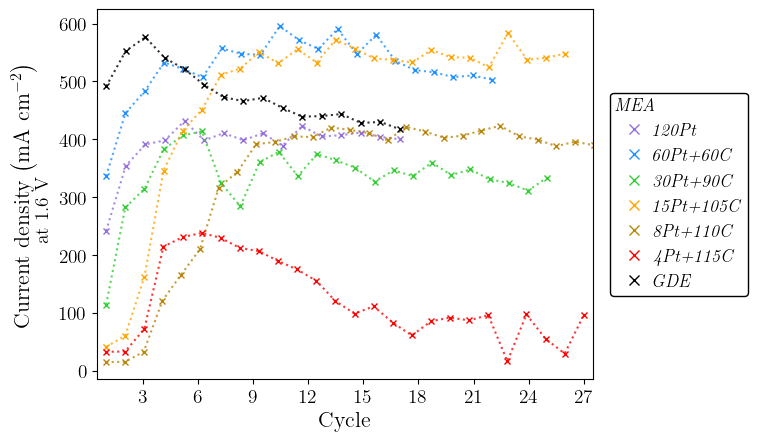

In [5]:

MEA = [s029,s041,s042,s046,s049,s050,s028]

# labels = ['\emph{MEA 120Pt}','\emph{MEA 60Pt+60C}','\emph{MEA 30Pt+90C}','\emph{MEA 15Pt+105C}','\emph{MEA 8Pt+110C}','\emph{MEA 4Pt+115C}','\emph{MEA GDE}']
labels = ['\emph{120Pt}','\emph{60Pt+60C}','\emph{30Pt+90C}','\emph{15Pt+105C}','\emph{8Pt+110C}','\emph{4Pt+115C}','\emph{GDE}']


for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['red', 'darkgoldenrod','orange' , 'limegreen', 'dodgerblue', 'mediumpurple']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [1.6]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)
                
                # print(index)
                # Iatu.append()
                # plt.plot(I[index],U[index],'x')
                
for uc,u in enumerate(voltage):
    lines = []
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        if mea['name'] == '028':
            line,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c='black')
            plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c='black',alpha = 0.8)
        else:
            line,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c=colors[5-index])
            plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[5-index],alpha = 0.8)
        lines.append(line)

        print(mea['name'],index)
        
    plt.xlim(1,15)
    # print(mea['iatu'][uc])
    custom_order = [0, 3, 1, 4, 2, 5, 6] 
    
    plt.legend(title = '\emph{MEA}',loc='center right', bbox_to_anchor=(1.33, 0.5),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

    xticks = np.arange(0, 30, 3)  # Every third tick
    xlabels = [str(3*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
    plt.xticks(xticks, xlabels,size = 14)
    plt.xlim(0.5,27.5)

    # plt.text(21,1500,r'$V = \mathrm{2.0~V}$',size = 18)

    plt.yticks(size = 14)
    plt.xlabel("Cycle",size=16)
    plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16,labelpad = 16)
    # plt.text(-3.2, 2000, "at 1.6 V", rotation=90, va='center', ha='center', fontsize=14)
    plt.text(-2.45, 280, "at 1.6 V", rotation=90, va='center', ha='center', fontsize=14)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/stability_high_C_'+str(u)+'.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()

### break-in high thickness series

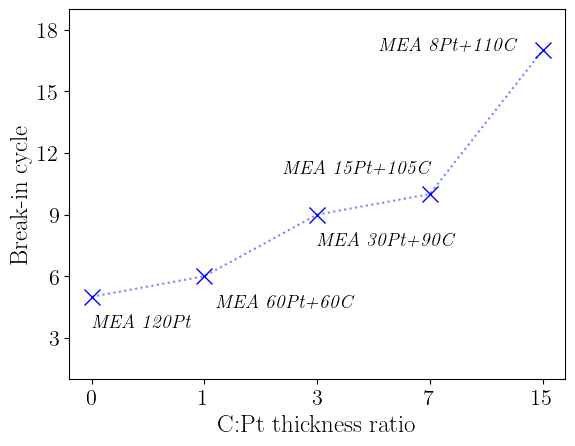

In [31]:
MEA = [s029,s041,s042,s046,s049]

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


voltage = [2]
# voltage = [1.6,1.7,1.8,1.9,2]
for mea in MEA:
    # mea['iatu'] = [[],[],[],[],[]]
    mea['iatu'] = [[]]
    for cycle,file in enumerate(mea['files']):
        d = np.loadtxt(file)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)

cmap = plt.get_cmap('rainbow')
# colors = cmap(np.linspace(0,1,len(MEA)+1)) 
colors = ['red', 'orange' , 'limegreen', 'dodgerblue', 'mediumpurple']


labels = ['0','1:1','3:1','7:1','15:1']
ratio = [0.5,1,3,7,15]
for uc,u in enumerate(voltage):
    break_ins = []
    for i,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        # plt.plot(t,np.array(mea['iatu'][uc])/4.84,label = labels[i],c=colors[i])
        threshold = 0.9*np.max(mea['iatu'][uc])/4.84
        
        
        index = next((i for i, x in enumerate(np.array(mea['iatu'][uc])/4.84) if x > threshold), None)
        # plt.axvline(index,color = colors[i],ls = '--')
        break_ins.append(index)

    # labels = ['120 nm Pt','60 nm Pt','30 nm Pt','15 nm Pt','8 nm Pt']
    xlabels = ["0","1","3","7","14"]
    xticks = [1,2,3,4,5]
    plt.plot(xticks,np.array(break_ins)+1,'x',markersize = '12', c = 'blue')
    plt.plot(xticks,np.array(break_ins)+1,':',markersize = '12', c = 'blue',alpha = 0.5)
    
    # xticks = [1,2,3,4,5]
    # for i,rati in enumerate(xlabels):
        
    # plt.ylim(-0.1,19)
    plt.text(1,3.5,'\emph{MEA 120Pt}',size = 14)
    plt.text(2.1,4.5,'\emph{MEA 60Pt+60C}',size = 14)
    plt.text(3,7.5,'\emph{MEA 30Pt+90C}',size = 14)
    plt.text(2.7,11,'\emph{MEA 15Pt+105C}',size = 14)
    plt.text(3.55,17,'\emph{MEA 8Pt+110C}',size = 14)
    # labels = [,,'MEA 30Pt+90C','MEA 15Pt+105C','MEA 8Pt+110C']

    # plt.text(xticks[i]-0.1,np.array(break_ins)[i]-2,labels[i],size = 14)
    
    plt.xlabel('C:Pt thickness ratio',size = 18)
    plt.ylabel('Break-in cycle',size = 18)
    # plt.title('Break-in time at '+f'{u:.1f}'+' V',size = 20)


    xlabels = ["0","1","3","7","15"]
    yticks = [3,6,9,12,15,18]
    # plt.xscale('log')
      # Label as 1, 2, 3, ...

    plt.xticks(xticks,xlabels,size = 16)
    plt.yticks(yticks,size = 16)
    plt.ylim(1,19)
    
#     plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/break-in high thickness series.png',dpi = 1000, format = 'png', bbox_inches = 'tight')


    plt.show()

### 8Pt+xC_loading_series

049 0
055 1
065 2
120 3
094 4
098 5
028 6


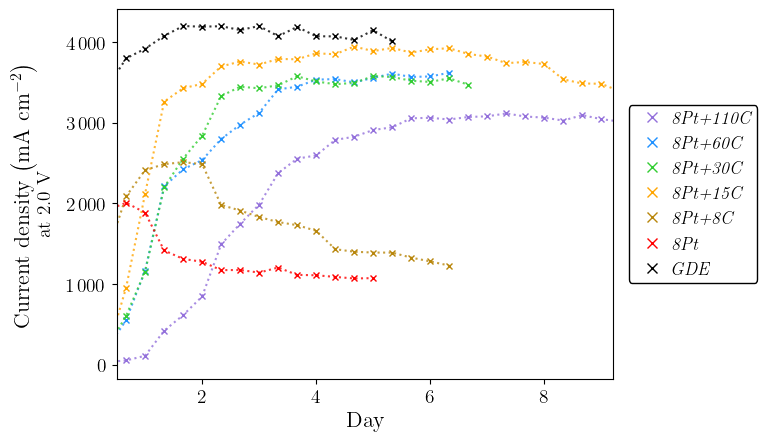

In [29]:
MEA = [s049,s055,s065,s120,s094,s098,s028] 

# labels = ['110','60','30','15','8','0','GDE']
labels = ['\emph{8Pt+110C}','\emph{8Pt+60C}','\emph{8Pt+30C}','\emph{8Pt+15C}','\emph{8Pt+8C}','\emph{8Pt}','\emph{GDE}']

# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['red', 'darkgoldenrod','orange' , 'limegreen', 'dodgerblue', 'mediumpurple']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [2]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)
                
                # print(index)
                # Iatu.append()
                # plt.plot(I[index],U[index],'x')
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles'],mea['cycles'])
        if mea['name'] == '028':
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c='black')
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,':',c='black',alpha = 0.8)
        else:
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = labels[index],c=colors[5-index])
            plt.plot(t/3,np.array(mea['iatu'][uc])/4.84,':',c=colors[5-index],alpha = 0.8)
  

        print(mea['name'],index)
        
    
    plt.legend(loc='center right', bbox_to_anchor=(1.31, 0.5),
                fontsize=13, ncol=1,handletextpad = 0.1,columnspacing = 0.5,borderpad = 0.3,
                title_fontsize = 13,alignment = 'left',markerscale = 1.8,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

    xticks = np.arange(0, 30, 2)  # Every third tick
    xlabels = [str(2*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...
    
    plt.xticks(xticks, xlabels,size = 14)
    plt.yticks(size = 14)
    plt.xlabel("Day",size=16)
    # plt.ylabel(r'$\begin{array}{c}\text{Main Label} \\ \text{(units)}\end{array}$',size=16)
    plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16,labelpad = 21)
    plt.text(-0.75, 2000, "at 2.0 V", rotation=90, va='center', ha='center', fontsize=14)

    plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/8Pt+xC_loading_series_'+str(u)+'.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
    plt.xlim(0.5,9.2)
    plt.show()

### break-in 8-nm-Pt series

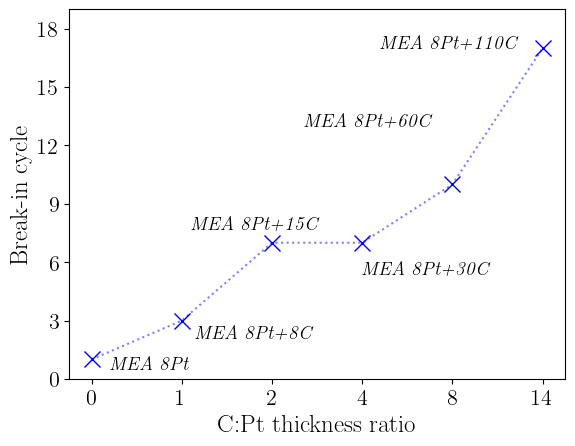

In [32]:
MEA = [s098,s094,s120,s065,s055,s049] 
# MEA = [s034,s047,s098,s093]
# MEA = [s111]
# MEA = [s046,s047]

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


voltage = [2]
# voltage = [1.6,1.7,1.8,1.9,2]
for mea in MEA:
    # mea['iatu'] = [[],[],[],[],[]]
    mea['iatu'] = [[]]
    for cycle,file in enumerate(mea['files']):
        d = np.loadtxt(file)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)

cmap = plt.get_cmap('rainbow')
# colors = cmap(np.linspace(0,1,len(MEA)+1)) 
colors = ['red', 'orange' , 'limegreen', 'dodgerblue', 'mediumpurple']


# labels = ['0','1:1','3:1','7:1','15:1','100']
ratio = [0.5,1,3,7,15,100]
for uc,u in enumerate(voltage):
    break_ins = []
    for i,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        # plt.plot(t,np.array(mea['iatu'][uc])/4.84,label = labels[i],c=colors[i])
        threshold = 0.9*np.max(mea['iatu'][uc])/4.84
        
        
        index = next((i for i, x in enumerate(np.array(mea['iatu'][uc])/4.84) if x > threshold), None)
        # plt.axvline(index,color = colors[i],ls = '--')
        break_ins.append(index)

    # labels = ['120 nm Pt','60 nm Pt','30 nm Pt','15 nm Pt','8 nm Pt']
    xlabels = ["0","1","3","7","14","100"]
    xticks = [1,2,3,4,5,6]
    plt.plot(xticks,np.array(break_ins)+1,'x',markersize = '12', c = 'blue')
    plt.plot(xticks,np.array(break_ins)+1,':',markersize = '12', c = 'blue',alpha = 0.5)
    
    # xticks = [1,2,3,4,5]
    # for i,rati in enumerate(xlabels):
        
    # plt.ylim(-0.1,19)
    plt.text(1.2,0.5,'\emph{MEA 8Pt}',size = 14)
    plt.text(2.15,2.1,'\emph{MEA 8Pt+8C}',size = 14)
    plt.text(2.1,7.7,'\emph{MEA 8Pt+15C}',size = 14)
    plt.text(4,5.4,'\emph{MEA 8Pt+30C}',size = 14)
    plt.text(3.35,13,'\emph{MEA 8Pt+60C}',size = 14)
    plt.text(4.2,17,'\emph{MEA 8Pt+110C}',size = 14)
    # labels = [,,'MEA 30Pt+90C','MEA 15Pt+105C','MEA 8Pt+110C']

    # plt.text(xticks[i]-0.1,np.array(break_ins)[i]-2,labels[i],size = 14)
    
    plt.xlabel('C:Pt thickness ratio',size = 18)
    plt.ylabel('Break-in cycle',size = 18)
    # plt.title('Break-in time at '+f'{u:.1f}'+' V',size = 20)


    xlabels = ["0","1","2","4","8","14"]
    yticks = [0,3,6,9,12,15,18]
    # plt.xscale('log')
      # Label as 1, 2, 3, ...

    plt.xticks(xticks,xlabels,size = 16)
    plt.yticks(yticks,size = 16)
    plt.ylim(0,19)
    
#     plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/break-in 8-nm-Pt series.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
    plt.show()

### peak performance double

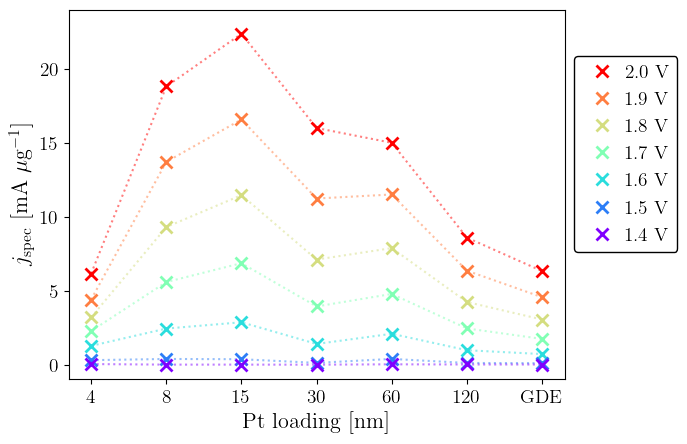

In [15]:

#Vybrat jestli je proudová hustota reálná, nebo specifická:::
spec = True


MEA = [s050,s049,s046,s042,s041,s029,s028]

soubory = []
for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['file'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))[mea['best_cycle']]# print(glob(os.path.join('C:/Users/Herman/Desktop/MFF/Bakalarka/Data z PEMWE/SV/'+mea['name']+'_peak_performance.txt')))
    # mea['file'] = glob(os.path.join('C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/'+mea['name']+'*/SV/',mea['name']+'_cycle_rising_*'+'*.txt'))mea['best_cycle']
    # glob(os.path.join('C:/Users/Herman/Desktop/MFF/Bakalarka/Data z PEMWE/SV/'+mea+'_peak_performance.txt'))
    # print(mea['file'])
    d = np.loadtxt(mea['file'], skiprows=1)
    I = d[:,0]
    U = d[:,1]
    mea['U'] = [1.4,1.5,1.6,1.7,1.8,1.9,2]
    mea['I'] = []
    for u in [1.4,1.5,1.6,1.7,1.8,1.9,2]:
        mea['I'].append(I[(np.abs(u - U)).argmin()])
#     print(mea['U'],mea['I'])
    # mea['U'] = d[:,0]
    # mea['I'] = d[:,3]

xlabels=['4','8','15','30','60','120','GDE']
loadings = [3.7,7.5,15,30,60,120,240]
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,7)) 
labels=['2.0 V','1.9 V','1.8 V','1.7 V','1.6 V','1.5 V','1.4 V']
xpos = [1,2,3,4,5,6,7]

for i,u in enumerate(labels):
    I_at_u = []
    for mea in MEA:
        I_at_u.append(mea['I'][-i-1])
    
    if spec == True:
        plt.plot(xpos, np.array(I_at_u)/(4.84*(np.array(loadings)*2.1+160)),':',c=colors[-1-i],alpha = 0.5)
        plt.plot(xpos,np.array(I_at_u)/(4.84*(np.array(loadings)*2.1+160)),'x',c=colors[-i-1],label = labels[i],markersize=8,mew=2)
    else:  
        plt.plot(xpos, np.array(I_at_u)/4.84,':',c=colors[-i-1],alpha = 0.5)
        plt.plot(xpos, np.array(I_at_u)/4.84,'x',c=colors[-i-1],label = labels[i],markersize=8,mew=2)

# plt.xticks(xlabels)
plt.legend(loc='upper left',bbox_to_anchor = (1,0.9),handletextpad=0.2,fontsize=14,edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
# xticks = ['0.85','1.7','3.5','7','14','28','56','112','224']
plt.xticks(xpos,xlabels,size=14)
plt.yticks(size=14)
# plt.xlabel('Pt loading [$\mathrm{\mu g ~ cm^{-2}}$]',size=16)
plt.xlabel('Pt loading [$\mathrm{nm}$]',size=16)
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
 
if spec == True:
    plt.ylim(-1,24)
    plt.ylabel('$j_{\mathrm{spec}}$ [$\mathrm{mA}~\mathrm{\mu g}^{-1} $] ',size=16)

    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/performance_na_loadingu_normalizovana.png',dpi = 500, format = 'png', bbox_inches = 'tight')
else:
    plt.ylabel('$j$ [$\mathrm{mA~cm^{-2}}$] ',size=16)
    plt.ylim(-200,4601)
    # plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/performance_na_loadingu_abs.png',dpi = 500, format = 'png', bbox_inches = 'tight')
plt.show()

### MEA120 slow degradation new

049 0
120 1
049 0
120 1


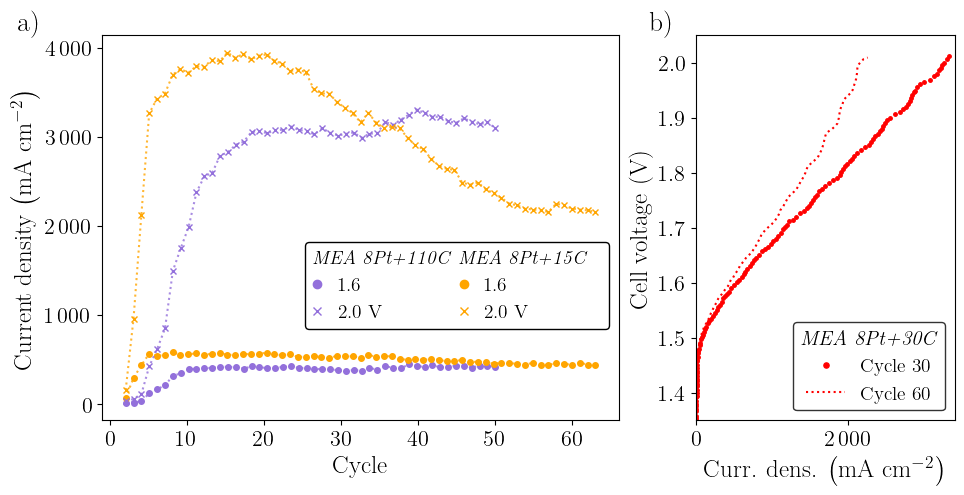

In [9]:
MEA = [s049,s120]

# labels = ['110','60','30','15','8','0','GDE']
labels = ['MEA 8Pt+110C','MEA 8Pt+15C']

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = [  'mediumpurple','orange']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [1.6,2]
fig, [ax1,ax2] = plt.subplots(1,2,figsize = (11,5),gridspec_kw={'width_ratios': [2,1],'wspace': 0.2})
# fig.set_figwidth(11)
# fig.figure(figsize=(12,6))
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[],[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])

lines = []
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']+1,mea['cycles'])
        if u == 2:
            line ,= ax1.plot(t+1,np.array(mea['iatu'][uc])/4.84,'x',markersize = 4,label = str(format(u, '.1f'))+' V',c=colors[index])
        else:
            line ,= ax1.plot(t+1,np.array(mea['iatu'][uc])/4.84,'o',markersize = 4,label = str(format(u, '.1f')),c=colors[index])
        
        ax1.plot(t+1,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
        lines.append(line)

        print(mea['name'],index)
        
    # plt.xlim(1,15)

# Create fake patches as bold group headers
header_A = Patch(color='none', label='\emph{MEA 8Pt+110C}')
header_B = Patch(color='none', label='\emph{MEA 8Pt+15C}')

# Combine into one list, with headers before the group items
legend_elements = [header_A, lines[0], lines[2], header_B, lines[1],lines[3]]

# Plot legend
legend = ax1.legend(handles=legend_elements,loc='center right', bbox_to_anchor=(1, 0.35),
                fontsize=14, ncol=2,handletextpad = 0.3,columnspacing = -0.3,borderpad = 0.4,
                markerscale = 1.5,edgecolor='0',framealpha=1,handlelength=0.5,alignment = 'center')
   
    # Set x-ticks
xticks = np.arange(0, 61, 10)  # Every third tick
xlabels = [str(10*i) for i in range(0, len(xticks))]  # Label as 1, 2, 3, ...

ax1.set_xticks(xticks, xlabels,size = 16)
# ax1.set_yticks('',size = 14)
ax1.tick_params('both',labelsize = 16)
ax1.set_xlabel("Cycle",size=18)
ax1.set_ylabel(r'Current density $\mathrm{\left( mA~cm^{-2} \right) }$',size=18)
ax1.yaxis.set_major_formatter(FuncFormatter(custom_format))
ax1.text(-12,4200,'a)',size = 20)
ax1.text(70,4200,'b)',size = 20)

for text in legend.get_texts():
    if text.get_text() in ['\emph{MEA 8Pt+15C}', '\emph{MEA 8Pt+110C}']:
        # width=item.get_window_extent(fig.canvas.get_renderer()).width
        # label.set_ha('left')
        text.set_position((-15,0))
    else:
        text.set_position((+10,0))

# inset_ax = plt.axes([1, 0.1, 0.4, 0.4])  # [x, y, width, height] in figure coordinates
d = np.loadtxt(s120['files'][29])
I = d[:,0]/4.84
U = d[:,1]
ax2.plot( I,U ,'.',markersize = 5, color='red',label = 'Cycle 30')


d = np.loadtxt(s120['files'][60])
I = d[:,0]/4.84
U = d[:,1]
ax2.plot( I,U ,':',markersize = 5, color='red',label = 'Cycle 60')

# print(I)
# inset_ax.plot(s047['U'][16,1:], 1000*s047['Ro'][16,1:]*4.84,':', color='darkorange',alpha = 0.5)
ax2.set_xlabel(r"Curr. dens. $\mathrm{\left( mA~cm^{-2} \right) }$",size = 18)
# ax2.xaxis.set_label_coords(0.5, -0.2)
ax2.tick_params('both',labelsize = 16)
ax2.set_ylabel(r'Cell voltage $\mathrm{\left(V \right) }$',size=18)
# inset_ax.set_xticks([1,2,3,4,5,6,7],['GDE',120,60,30,15,8,4],rotation = 50)
# inset_ax.tick_params(axis='both', labelsize=12) 
ax2.set_xlim(-0.5,3400)
ax2.set_ylim(1.35,2.05) 
ax2.xaxis.set_major_formatter(FuncFormatter(custom_format))  
ax2.legend(fontsize = 14,title = '\emph{MEA 8Pt+30C}',title_fontsize = 15,markerscale = 1.5,loc = 'lower right',edgecolor = 'black')
# plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/MEA120 slow degradation.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()

### PtOx in time

028 0
096 1
097 2
153 3
065 4


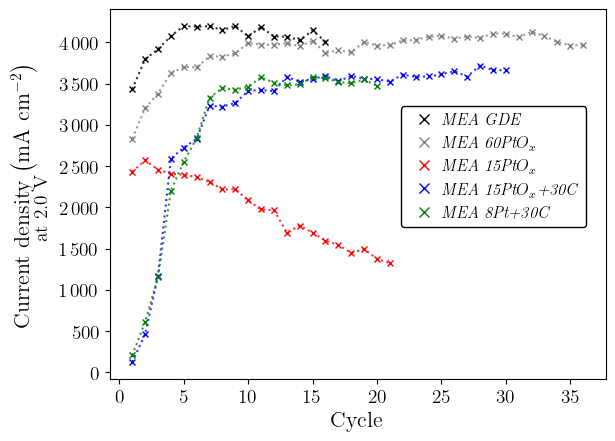

In [20]:
MEA = [s028,s096,s097,s153,s065] 
# MEA = [s034,s047,s098,s093]
# MEA = [s111]
# MEA = [s049,s120]

labels = ['\emph{MEA GDE}',r'\emph{MEA 60Pt$O_x$ }','\emph{MEA 15Pt$O_x$}','\emph{MEA 15Pt$O_x$+30C}','\emph{MEA 8Pt+30C}','\emph{MEA 15Pt}']
# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = ['black','grey', 'red','blue','green','violet']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [2]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])
                # time.append(cycle+1)
                
                # print(index)
                # Iatu.append()
                # plt.plot(I[index],U[index],'x')
ms = ['o','x']
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles'],mea['cycles'])

        plt.plot(t,np.array(mea['iatu'][uc])/4.84,marker = 'x',ls = '',markersize = 4,label = labels[index],c=colors[index])
        plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
  

        print(mea['name'],index)

plt.legend(fontsize = 12, bbox_to_anchor=(0.57, 0.76),handletextpad=0.1,markerscale = 1.8,edgecolor='0',framealpha=1)

plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlabel("Cycle",size=16)
plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16,labelpad = 16)
    # plt.text(-3.2, 2000, "at 1.6 V", rotation=90, va='center', ha='center', fontsize=14)
plt.text(-6, 2000, "at 2.0 V", rotation=90, va='center', ha='center', fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))
# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/PtOx in time.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

### 8Pt+Fe in time

049 0
143 1
049 0
143 1


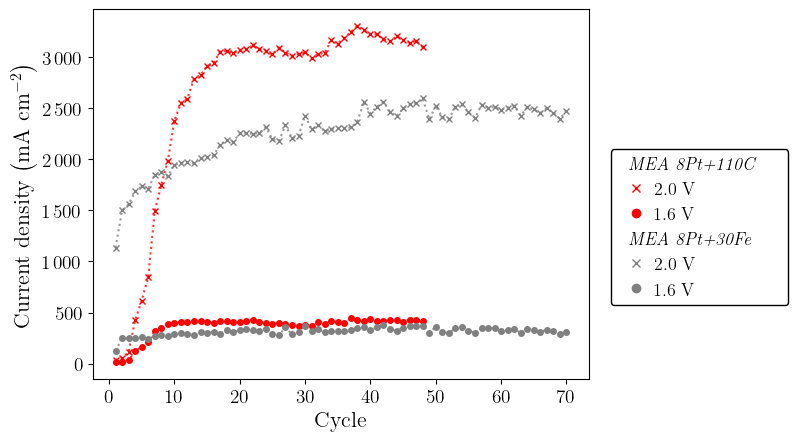

In [28]:
MEA = [s049,s143] 


labels = ['\emph{MEA 8Pt+30Fe}','\emph{MEA 8Pt+110C}']
# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = [ 'red','grey']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [2,1.6]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[],[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])

ms = ['x','o']
lines = []
napeti = ['2.0 V', '1.6 V']
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles'],mea['cycles'])

        line ,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,marker = ms[uc],ls = '',markersize = 4,label = napeti[uc],c=colors[index])
        plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
  
        lines.append(line)
        print(mea['name'],index)
        
# Create fake patches as bold group headers
header_B = Patch(color='none', label='\emph{MEA 8Pt+30Fe}')
header_A = Patch(color='none', label='\emph{MEA 8Pt+110C}')

# Combine into one list, with headers before the group items
legend_elements = [header_A, lines[0],lines[2], header_B, lines[1] ,lines[3]]

legend = plt.legend(handles=legend_elements,loc='center right', bbox_to_anchor=(1.42, 0.41),
                fontsize=13, ncol=1,columnspacing = 0.5,
                markerscale = 1.5,edgecolor='0',framealpha=1,handletextpad = 0)



plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlabel("Cycle",size=16)
plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))

for text in legend.get_texts():
    if text.get_text() in ['\emph{MEA 8Pt+30Fe}', '\emph{MEA 8Pt+110C}']:
        # width=item.get_window_extent(fig.canvas.get_renderer()).width
        # label.set_ha('left')
        text.set_position((-25,0))

# plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/8Pt+Fe in time.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

098 0
120 1
098 0
120 1


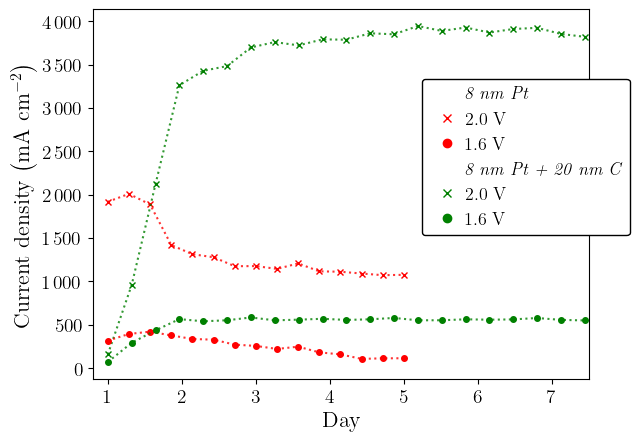

In [2]:
MEA = [s098,s120] 


labels = ['\emph{MEA 8Pt+30Fe}','\emph{MEA 8Pt+110C}']
# labels = ['Pt + C','Pt, no C']

for mea in MEA:
    folder_path = glob("C:/Users/Herman/Desktop/MFF/Diplomka/Data z PEMWE/"+mea['name']+'*/SV')   
    mea['files'] =  glob(os.path.join(str(folder_path[0]),mea['name']+'_cycle_rising*'))
    mea['cycles'] = len(mea['files'])


cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,len(MEA)-1))
colors = [ 'red','green']
# colors =  ['crimson', 'chocolate', 'yellowgreen', 'teal', 'royalblue', 'blueviolet']
# print(list(colors))

voltage = [2,1.6]
# voltage = [1.4,1.5,1.6,1.7,1.8,1.9,2]
for mea in MEA:
    mea['iatu'] = [[],[]]
    # mea['iatu'] = [[],[],[],[],[],[],[]]
    for cycle,file in enumerate(mea['files']):
        # print(file)
        d = np.loadtxt(file,skiprows = 1)
        I = d[:,0]
        U = d[:,1]
            # for uc,u in enumerate([1.4,1.5,1.6,1.7,1.8,1.9,2]):
        for uc,u in enumerate(voltage):
            index = np.argmin(np.abs(U - u))
            mea['iatu'][uc].append(I[index])

ms = ['x','o']
lines = []
napeti = ['2.0 V', '1.6 V']
for uc,u in enumerate(voltage):
    for index,mea in enumerate(MEA):
        t = np.linspace(1,mea['cycles']/3,mea['cycles'])

        line ,= plt.plot(t,np.array(mea['iatu'][uc])/4.84,marker = ms[uc],ls = '',markersize = 4,label = napeti[uc],c=colors[index])
        plt.plot(t,np.array(mea['iatu'][uc])/4.84,':',c=colors[index],alpha = 0.8)
  
        lines.append(line)
        print(mea['name'],index)
        
# Create fake patches as bold group headers
header_A = Patch(color='none', label='\emph{8 nm Pt}')
header_B = Patch(color='none', label='\emph{8 nm Pt + 20 nm C}')

# Combine into one list, with headers before the group items
legend_elements = [header_A, lines[0],lines[2], header_B, lines[1] ,lines[3]]

legend = plt.legend(handles=legend_elements,loc='center right', bbox_to_anchor=(1.1, 0.6),
                fontsize=13, ncol=1,columnspacing = 0.5,
                markerscale = 1.5,edgecolor='0',framealpha=1,handletextpad = 0)



plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlabel("Day",size=16)
plt.ylabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.gca().yaxis.set_major_formatter(FuncFormatter(custom_format))

for text in legend.get_texts():
    if text.get_text() in ['\emph{MEA 8Pt+30Fe}', '\emph{MEA 8Pt+110C}']:
        # width=item.get_window_extent(fig.canvas.get_renderer()).width
        # label.set_ha('left')
        text.set_position((-25,0))
plt.xlim(0.8,7.5)
plt.savefig('C:/Users/Herman/Desktop/MFF/Diplomka/Grafy/8Pt+C,8Pt in time.jpg',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()